In [1]:
import torch

print("Number of GPUs available:", torch.cuda.device_count())
print("CUDA is available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name())


Number of GPUs available: 1
CUDA is available: True
GPU Name: NVIDIA GeForce RTX 4070


# Agent 1 — Demand Predictor (Velocity Model) 

**v2 result:** the log-ratio head worked. h6 went from RelMAE 1.47 (v1, losing to the naive
rule) to **0.725**, bootstrap CI **[0.617, 0.830]** — excludes 1.0. CV RelMAE 0.783 ± 0.039.
That is the headline and it survives.

**What v3 fixes**, all found by reading the v2 outputs:

| # | Problem in the v2 run | Fix |
|---|---|---|
| 1 | `Best round: 3000` = `n_estimators: 3000` — **early stopping never fired**. Val L2 was still falling and the train/val gap was only 0.011. The model was budget-capped, not converged. | `n_estimators=20000` + an explicit assert that stopping actually fired. Repeated fits reuse a budget derived from the converged best round. |
| 2 | Ablation had no row isolating the engineered features *inside* the head — A→B→C all went the wrong way (1.2238 → 1.3099 → 1.3182) but nothing proved the features were dead weight. | New row **D** (log-ratio head, raw features only). D→E now isolates them, with an automatic verdict. |
| 3 | h3 read "no difference" at p=0.0524 despite dMAE **+23%**. The paired t-test is under-powered — its variance is owned by a few top-1% SKUs (d_z = 0.0064 at h6, yet Wilcoxon gave p=4e-39 vs the t-test's 5e-4). | **Wilcoxon is now the primary test** everywhere, including Section 19. The t-test is kept alongside it. |
| 4 | The RF baseline got the log1p treatment while the proposal got the log-ratio head — the table conflated *algorithm* with *parameterisation*. | Added **RF + log-ratio head**. That pair isolates the algorithm. |
| 5 | "MAE by Demand Decile" showed 7 bars labelled D1–D7. `qcut(10, duplicates="drop")` had silently collapsed the bins, because ~38% of the target is exactly 0. | Bins labelled by actual demand range, plus each bin's share of total volume. |
| 6 | Exact band accuracy 0.5693 with "Dead" at 1.0% predicted vs 38.3% actual zeros — the continuous head can never emit an exact 0, so the band was structurally unreachable. | Explicit Dead-band diagnostic. |
| 7 | RMSE reported as a headline despite a bootstrap CI of [622, 1406] — a 2.3× span. | Headline metrics marked; RMSE demoted to secondary. |

**The h9 result stands and is not a bug:** RelMAE **1.0886**, dMAE **−8.86%**. `sales_9 ⊇ sales_6`
is the tightest nesting in the schema (naive R² 0.9633), so there is almost nothing left to
correct. If fix #1 does not rescue it, report the negative result — Section 19 now says so
automatically.

## 1. Dependencies & Global Configuration

In [2]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn lightgbm shap scipy statsmodels joblib "pyarrow>=13.0.0"


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap
import lightgbm as lgb

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.dummy           import DummyRegressor
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import RobustScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH  = r"E:\CSE499B\Project Codes\Demand Predictor Velocity Model\Dataset\Processed_Dataset.pkl"
OUTPUT_DIR = "outputs"
MODEL_DIR  = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
Path(MODEL_DIR).mkdir(exist_ok=True)

USE_GPU  = False          # LightGBM GPU has no benefit at this size and can bin-quantise harder; CPU hist is fine
N_FOLDS  = 5
N_BOOT   = 2000

# --- plot theme (matched to the Supplier Auditor notebook) ---
BG, PANEL, GRID, WHITE = "#0f1117", "#1a1a2e", "#2a2a3e", "#e8e8f0"
TRAIN_C, VAL_C, BEST_C, GREEN = "#7c6af7", "#e74c3c", "#f1c40f", "#2ecc71"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "axes.edgecolor": GRID,
    "axes.labelcolor": WHITE, "xtick.color": WHITE, "ytick.color": WHITE,
    "text.color": WHITE, "grid.color": GRID, "grid.linewidth": 0.5,
    "legend.facecolor": PANEL, "legend.edgecolor": GRID, "legend.labelcolor": WHITE,
})
print("Environment ready. Outputs ->", f"./{OUTPUT_DIR}/")

Environment ready. Outputs -> ./outputs/


e:\CSE499B\Project Codes\Demand Predictor Velocity Model\erwin\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Dataset

Same processed dataset as the Supplier Auditor. One row = one SKU snapshot, so a random
(non-temporal) split is valid here — there is no time index to leak across.

In [4]:
df = pd.read_pickle(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

TARGET_COLS = ["sales_1_month", "sales_3_month", "sales_6_month", "sales_9_month"]
print("\nSales-window summary (note the tail):")
print(df[TARGET_COLS].describe(percentiles=[.5, .9, .99, .999]).T.to_string())

zero_frac = (df[TARGET_COLS] == 0).mean()
print("\nFraction of exact zeros per window:")
print(zero_frac.to_string())

Loaded 1,929,935 rows x 26 columns

Sales-window summary (note the tail):
                   count        mean           std  min  50%    90%     99%      99.9%        max
sales_1_month  1929935.0   55.368164   1884.377075  0.0  0.0   34.0   693.0   5775.000   741774.0
sales_3_month  1929935.0  174.663849   5188.855957  0.0  1.0  113.0  2229.0  18027.858  1105478.0
sales_6_month  1929935.0  341.565369   9585.030273  0.0  2.0  232.0  4410.0  35206.264  2146625.0
sales_9_month  1929935.0  523.577087  14733.265625  0.0  4.0  354.0  6698.0  54158.000  3205172.0

Fraction of exact zeros per window:
sales_1_month    0.570000
sales_3_month    0.450319
sales_6_month    0.383249
sales_9_month    0.347060


### 2.1 Cumulative-window sanity check

In this schema `sales_9_month` is a **cumulative** window that contains `sales_6_month`, which
contains `sales_3_month`, which contains `sales_1_month`. That is *why* the naive multiplier
baseline is so strong — and it is a fact the paper must state explicitly, otherwise a reviewer
will read "we forecast 9-month sales with R²=0.94" as a much bigger claim than it is.

In [5]:
mono = pd.Series({
    "sales_3 >= sales_1": (df.sales_3_month >= df.sales_1_month).mean(),
    "sales_6 >= sales_3": (df.sales_6_month >= df.sales_3_month).mean(),
    "sales_9 >= sales_6": (df.sales_9_month >= df.sales_6_month).mean(),
})
print("Monotonic-nesting rate (should be ~1.0 if windows are cumulative):")
print(mono.round(4).to_string())
if mono.min() > 0.98:
    print("\n-> Windows ARE cumulative. Report this in the paper; the h6/h9 tasks are")
    print("   'extrapolate a nested cumulative window', not 'forecast unseen demand'.")

Monotonic-nesting rate (should be ~1.0 if windows are cumulative):
sales_3 >= sales_1    1.0
sales_6 >= sales_3    1.0
sales_9 >= sales_6    1.0

-> Windows ARE cumulative. Report this in the paper; the h6/h9 tasks are
   'extrapolate a nested cumulative window', not 'forecast unseen demand'.


## 3. Exploratory Data Analysis

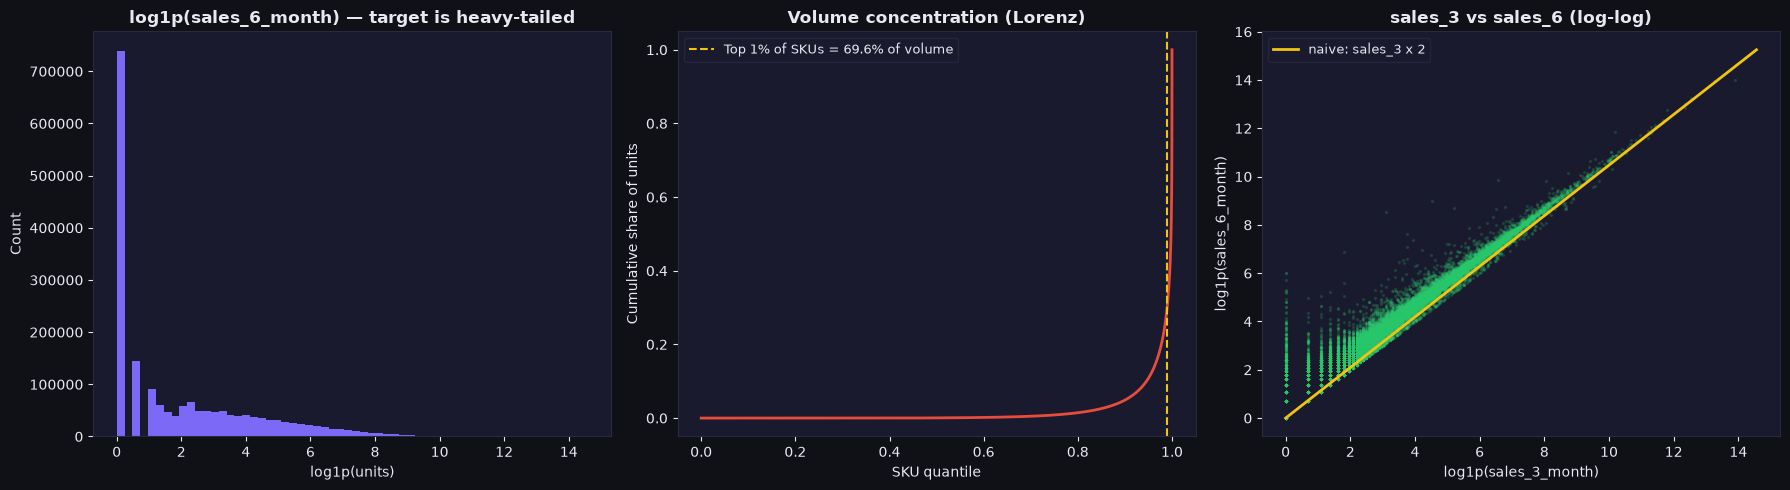

Top 1% of SKUs carry 69.6% of all 6-month volume.
This is the root cause of the v1 failure: plain L2 loss on raw units lets a few
thousand huge SKUs dominate every split decision, and 255-bin quantisation collapses
the entire tail into one bin, so the tree cannot reproduce even 'sales_3 x 2'.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

ax = axes[0]
ax.hist(np.log1p(df.sales_6_month), bins=60, color=TRAIN_C, edgecolor="none")
ax.set_title("log1p(sales_6_month) — target is heavy-tailed", fontweight="bold")
ax.set_xlabel("log1p(units)"); ax.set_ylabel("Count")

ax = axes[1]
q = df.sales_6_month.sort_values().values
cum = np.cumsum(q) / q.sum()
ax.plot(np.linspace(0, 1, len(cum)), cum, color=VAL_C, lw=2)
top1 = 1 - cum[int(0.99 * len(cum))]
ax.axvline(0.99, color=BEST_C, ls="--", lw=1.5, label=f"Top 1% of SKUs = {top1:.1%} of volume")
ax.set_title("Volume concentration (Lorenz)", fontweight="bold")
ax.set_xlabel("SKU quantile"); ax.set_ylabel("Cumulative share of units"); ax.legend(fontsize=9)

ax = axes[2]
sub = df.sample(min(50_000, len(df)), random_state=RANDOM_STATE)
ax.scatter(np.log1p(sub.sales_3_month), np.log1p(sub.sales_6_month), s=2, alpha=.15, color=GREEN)
lim = [0, np.log1p(sub.sales_6_month).max()]
ax.plot(lim, np.log1p(np.expm1(lim) * 2), color=BEST_C, lw=2, label="naive: sales_3 x 2")
ax.set_title("sales_3 vs sales_6 (log-log)", fontweight="bold")
ax.set_xlabel("log1p(sales_3_month)"); ax.set_ylabel("log1p(sales_6_month)"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_eda.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

print(f"Top 1% of SKUs carry {top1:.1%} of all 6-month volume.")
print("This is the root cause of the v1 failure: plain L2 loss on raw units lets a few")
print("thousand huge SKUs dominate every split decision, and 255-bin quantisation collapses")
print("the entire tail into one bin, so the tree cannot reproduce even 'sales_3 x 2'.")

## 4. Feature Engineering & Stage Definitions

Two changes from v1 that matter:

1. **The naive baseline is now a feature** (`base_pred`). A model that is handed the baseline can
   never do *worse* than it for structural reasons — it only has to learn the correction.
2. **The model predicts a log-ratio correction**, not the raw level:

$$\hat{y} = \exp\big(\log(1+b) + \hat{\delta}(x)\big) \cdot s - 1, \qquad
\delta = \log(1+y) - \log(1+b)$$

where $b$ is the naive baseline and $s$ is the Duan smearing factor (Section 8). This makes the
learning target roughly symmetric and unit-free, which is exactly what a piecewise-constant tree
ensemble can actually fit.

In [7]:
EPS = 1e-6

def engineer_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["velocity_1m"]        = d["sales_1_month"] / 30.0
    d["velocity_3m"]        = d["sales_3_month"] / 90.0
    d["accel_3_vs_1"]       = d["velocity_3m"] / (d["velocity_1m"] + EPS)
    d["cover_days_1m"]      = d["national_inv"] / (d["velocity_1m"] + EPS)
    d["transit_cover"]      = d["in_transit_qty"] / (d["velocity_1m"] + EPS)
    d["bo_pressure"]        = d["local_bo_qty"] / (d["sales_1_month"] + 1.0)   # Agent-1's brief signal
    d["inv_to_min_bank"]    = d["national_inv"] / (d["min_bank"] + EPS)
    d["lead_time_demand"]   = d["lead_time"] * d["velocity_1m"]
    d["forecast_bias_3m"]   = d["forecast_3_month"] - d["sales_3_month"]
    d["log_sales_1m"]       = np.log1p(d["sales_1_month"])
    d["log_national_inv"]   = np.log1p(d["national_inv"].clip(lower=0))
    d["risk_flag_count"]    = d[["deck_risk", "oe_constraint", "ppap_risk", "rev_stop"]].sum(axis=1)
    return d

df_eng = engineer_features(df)

CONTEXT_FEATURES = [
    "national_inv", "lead_time", "in_transit_qty", "min_bank",
    "perf_6_month_avg", "perf_12_month_avg", "local_bo_qty",
    "deck_risk", "oe_constraint", "ppap_risk", "stop_auto_buy",
    "safety_gap", "perf_gap",
]
ENGINEERED_FEATURES = [
    "velocity_1m", "velocity_3m", "accel_3_vs_1", "cover_days_1m", "transit_cover",
    "bo_pressure", "inv_to_min_bank", "lead_time_demand", "forecast_bias_3m",
    "log_sales_1m", "log_national_inv", "risk_flag_count",
]

STAGES = {
    "h3": dict(target="sales_3_month",
               extra=["sales_1_month", "inv_velocity"],
               baseline_fn=lambda d: d["sales_1_month"] * 3.0,
               baseline_name="sales_1_month x 3"),
    "h6": dict(target="sales_6_month",
               extra=["sales_1_month", "inv_velocity", "sales_3_month", "sales_trend"],
               baseline_fn=lambda d: d["sales_3_month"] * 2.0,
               baseline_name="sales_3_month x 2"),
    "h9": dict(target="sales_9_month",
               extra=["sales_1_month", "inv_velocity", "sales_3_month", "sales_trend", "sales_6_month"],
               baseline_fn=lambda d: d["sales_6_month"] * 1.5,
               baseline_name="sales_6_month x 1.5"),
}

def stage_matrix(d, stage, use_engineered=True, with_base=True):
    """Returns (X dataframe, y, baseline). Never leaks a future window into an earlier stage."""
    cfg  = STAGES[stage]
    cols = CONTEXT_FEATURES + cfg["extra"] + (ENGINEERED_FEATURES if use_engineered else [])
    if stage == "h3":   # velocity_3m / accel / forecast_bias_3m are built from sales_3_month = the h3 target
        cols = [c for c in cols if c not in ("velocity_3m", "accel_3_vs_1", "forecast_bias_3m")]
    cols = [c for c in dict.fromkeys(cols) if c in d.columns]
    X = d[cols].copy()
    b = cfg["baseline_fn"](d).astype(float)
    if with_base:
        X["base_pred"]     = b.values
        X["log_base_pred"] = np.log1p(b.clip(lower=0)).values
    return X, d[cfg["target"]].astype(float).values, b.values

Xh6, yh6, bh6 = stage_matrix(df_eng, "h6")
print(f"h6 design matrix: {Xh6.shape[0]:,} rows x {Xh6.shape[1]} features")
print("Leakage guard: each stage only sees sales windows strictly shorter than its target.")

h6 design matrix: 1,929,935 rows x 31 features
Leakage guard: each stage only sees sales windows strictly shorter than its target.


## 5. Three-Way Split & Preprocessing

`Train (70%) → fit + early stopping · Val (15%) → smearing calibration · Test (15%) → reported once.`

Stratified on a **demand decile** so every split has the same share of high-volume SKUs — with a
tail this heavy, an unstratified split is where the ±808 RMSE fold-to-fold swing in v1 came from.

In [8]:
STAGE = "h6"   # <- the reference stage used throughout Sections 5-16; Section 19 loops over all three

X_all, y_all, b_all = stage_matrix(df_eng, STAGE)
strata = pd.qcut(np.log1p(y_all), q=10, labels=False, duplicates="drop")

idx = np.arange(len(y_all))
idx_tv, idx_te = train_test_split(idx, test_size=.15, stratify=strata, random_state=RANDOM_STATE)
idx_tr, idx_va = train_test_split(idx_tv, test_size=.1765,
                                  stratify=strata[idx_tv], random_state=RANDOM_STATE)

def take(i): return X_all.iloc[i], y_all[i], b_all[i]
X_tr, y_tr, b_tr = take(idx_tr)
X_va, y_va, b_va = take(idx_va)
X_te, y_te, b_te = take(idx_te)

FEATURE_COLS = list(X_all.columns)

for nm, (xx, yy) in [("Train", (X_tr, y_tr)), ("Val", (X_va, y_va)), ("Test", (X_te, y_te))]:
    print(f"  {nm:<6}: {len(yy):>9,} rows ({len(yy)/len(y_all):.1%})  "
          f"mean={yy.mean():>9.2f}  p99={np.percentile(yy,99):>10.1f}")
print(f"\nFeatures: {len(FEATURE_COLS)}")

  Train : 1,350,905 rows (70.0%)  mean=   339.13  p99=    4421.0
  Val   :   289,539 rows (15.0%)  mean=   330.41  p99=    4374.2
  Test  :   289,491 rows (15.0%)  mean=   364.08  p99=    4400.0

Features: 31


## 6. Training — Log-Ratio Correction Head

LightGBM is trained on $\delta = \log(1+y) - \log(1+b)$ with early stopping on the val set.
`max_bin` is raised from the 255 default because the v1 GPU trainer was quantising a 6-order-of-
magnitude feature into 255 buckets, which is what destroyed the tail.

In [9]:
LGB_PARAMS = dict(
    objective         = "regression",
    n_estimators      = 30000,          # was 8000 -> early stopping never fired
    learning_rate     = 0.15,
    num_leaves        = 127,
    min_child_samples = 100,
    subsample         = 0.8,
    subsample_freq    = 1,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    max_bin           = 1023,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)
if USE_GPU:
    LGB_PARAMS["device"] = "gpu"

STRICT_CONVERGENCE = True   # set False only to smoke-test the notebook end-to-end

def to_delta(y, b):  return np.log1p(np.maximum(y, 0)) - np.log1p(np.maximum(b, 0))
def from_delta(d, b, smear=1.0):
    return np.maximum((1.0 + np.maximum(b, 0)) * np.exp(d) * smear - 1.0, 0.0)

# log1p-target analogue of from_delta (b = 0). Used by the baselines in Section 11.
def from_log1p(p_log, smear=1.0):
    return np.maximum(np.exp(p_log) * smear - 1.0, 0.0)

d_tr, d_va = to_delta(y_tr, b_tr), to_delta(y_va, b_va)

model = lgb.LGBMRegressor(**LGB_PARAMS)
model.fit(
    X_tr, d_tr,
    eval_set=[(X_tr, d_tr), (X_va, d_va)],
    eval_names=["train", "val"],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(1000)],
)

hist        = model.evals_result_
TRAIN_LOSS  = hist["train"]["l2"]
VAL_LOSS    = hist["val"]["l2"]
BEST_ROUND  = model.best_iteration_
ROUNDS      = list(range(1, len(TRAIN_LOSS) + 1))
FIRED       = BEST_ROUND < LGB_PARAMS["n_estimators"] - 1

print(f"\nBest round      : {BEST_ROUND}  of {LGB_PARAMS['n_estimators']} allowed")
print(f"Val L2 @ best   : {VAL_LOSS[BEST_ROUND-1]:.6f}  (in log-ratio space)")
print(f"Train/Val gap   : {VAL_LOSS[BEST_ROUND-1] - TRAIN_LOSS[BEST_ROUND-1]:.6f}")

# How much was val L2 still moving over the last 500 rounds before the stop?
tail = VAL_LOSS[max(0, BEST_ROUND-500):BEST_ROUND]
if len(tail) > 1:
    drift = (tail[0] - tail[-1]) / max(tail[0], 1e-12)
    print(f"Val L2 drift over last {len(tail)} rounds: {drift:+.5%} "
          f"({'flat -> converged' if abs(drift) < 0.002 else 'still moving'})")

if not FIRED:
    msg = (f"EARLY STOPPING DID NOT FIRE at n_estimators={LGB_PARAMS['n_estimators']}. "
           "The model is budget-capped, not converged. Every downstream number "
           "(test, CV, ablation, SHAP, significance) is invalid until this passes. "
           "Raise n_estimators and rerun.")
    if STRICT_CONVERGENCE:
        raise RuntimeError(msg)      # hard stop — do not let the notebook run on
    print("\n[!] " + msg)
else:
    print(f"\n[OK] Early stopping fired at {BEST_ROUND} with "
          f"{LGB_PARAMS['n_estimators'] - BEST_ROUND} rounds of headroom.")

# Repeated fits (CV / ablation / all-stages) reuse the converged budget.
# Early stopping stays ON inside those fits; this is a ceiling, not a fixed count.
CV_BUDGET     = int(max(1000, BEST_ROUND))
LGB_PARAMS_CV = {**LGB_PARAMS, "n_estimators": CV_BUDGET}
print(f"\nRepeated-fit budget (CV/ablation/stages): {CV_BUDGET} rounds "
      f"(= the converged best round of the main model)")

[1000]	train's l2: 0.0993208	val's l2: 0.113538
[2000]	train's l2: 0.0858529	val's l2: 0.105322
[3000]	train's l2: 0.0773183	val's l2: 0.10047
[4000]	train's l2: 0.0711689	val's l2: 0.097044
[5000]	train's l2: 0.0665223	val's l2: 0.0944894
[6000]	train's l2: 0.0628481	val's l2: 0.0925907
[7000]	train's l2: 0.0598888	val's l2: 0.0910189
[8000]	train's l2: 0.0574049	val's l2: 0.0897924
[9000]	train's l2: 0.0552994	val's l2: 0.08868
[10000]	train's l2: 0.0535277	val's l2: 0.0878101
[11000]	train's l2: 0.0519711	val's l2: 0.087103
[12000]	train's l2: 0.0506516	val's l2: 0.0864622
[13000]	train's l2: 0.049485	val's l2: 0.0859261
[14000]	train's l2: 0.0484756	val's l2: 0.0854811
[15000]	train's l2: 0.0475864	val's l2: 0.0850457
[16000]	train's l2: 0.0467854	val's l2: 0.0846858
[17000]	train's l2: 0.0460815	val's l2: 0.0843861
[18000]	train's l2: 0.0454429	val's l2: 0.0840939
[19000]	train's l2: 0.0448519	val's l2: 0.0838214
[20000]	train's l2: 0.04432	val's l2: 0.0836013
[21000]	train's l2: 

In [10]:
print("lr in params dict :", LGB_PARAMS["learning_rate"])
print("lr the model used :", model.get_params()["learning_rate"])

lr in params dict : 0.15
lr the model used : 0.15


## 7. Training Monitor — Learning Curves

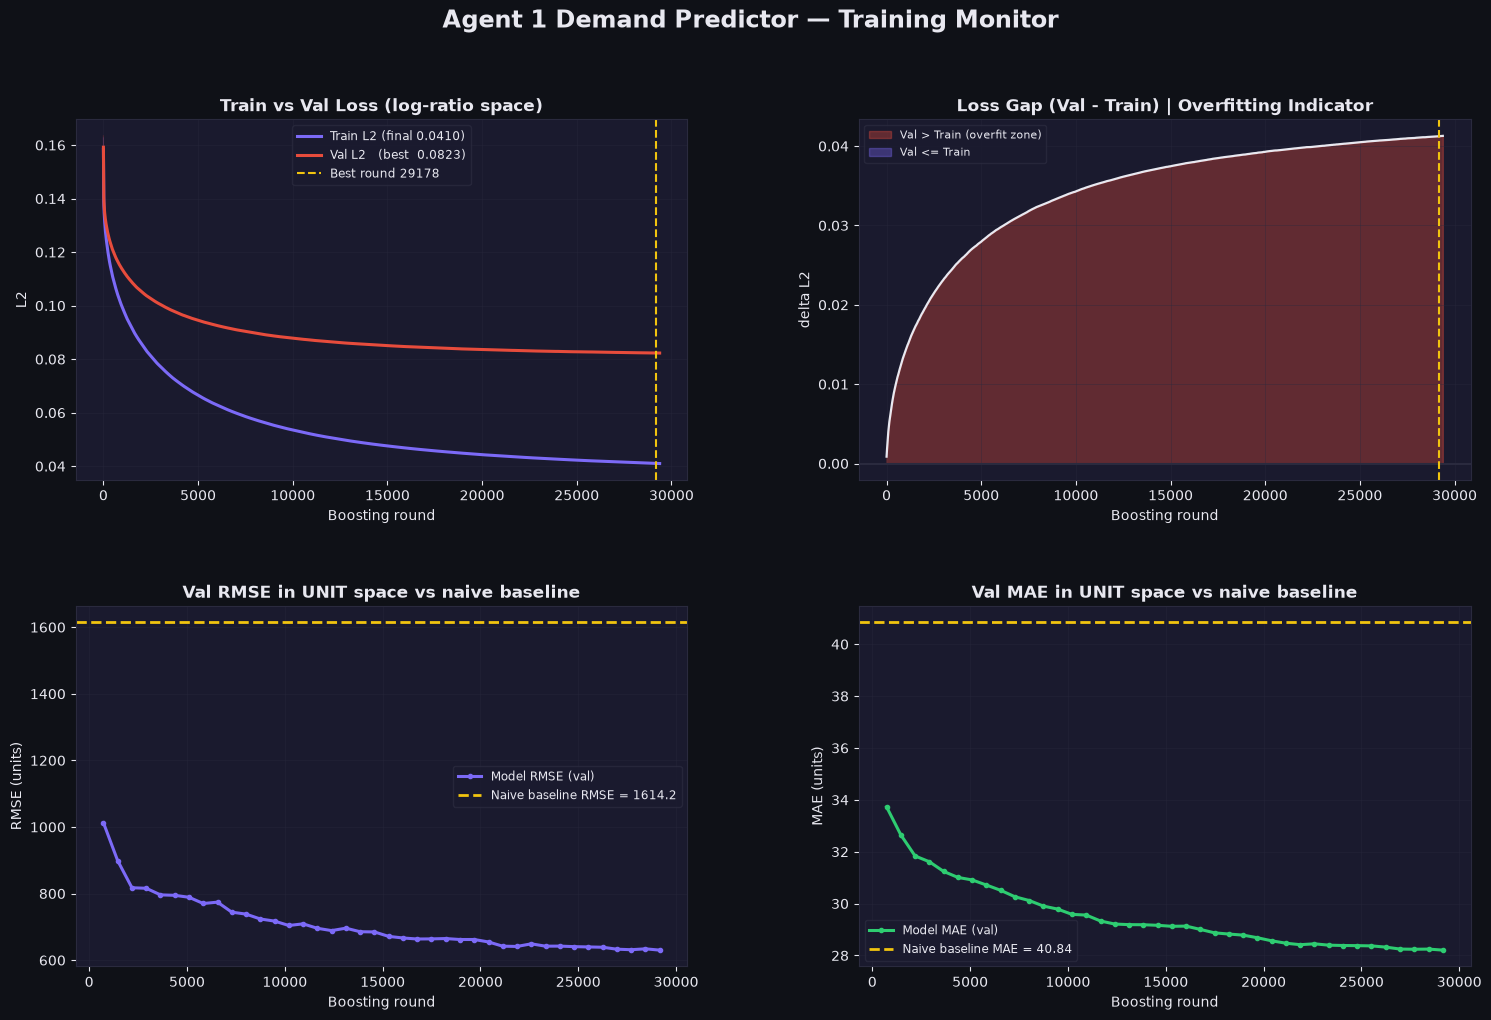

The two bottom panels are the ones that matter: if the purple/green line does not
sit BELOW the yellow dashed line, the trained model is not worth reporting.


In [11]:
def smooth(v, window=12):
    k = np.ones(window) / window
    p = np.pad(np.asarray(v, float), (window // 2, window // 2), mode="edge")
    return np.convolve(p, k, mode="valid")[:len(v)]

fig = plt.figure(figsize=(18, 11), facecolor=BG)
fig.suptitle("Agent 1 Demand Predictor — Training Monitor", fontsize=17, fontweight="bold",
             color=WHITE, y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=.35, wspace=.28)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ROUNDS, TRAIN_LOSS, color=TRAIN_C, alpha=.2, lw=.8)
ax1.plot(ROUNDS, VAL_LOSS,   color=VAL_C,   alpha=.2, lw=.8)
ax1.plot(ROUNDS, smooth(TRAIN_LOSS), color=TRAIN_C, lw=2.2, label=f"Train L2 (final {TRAIN_LOSS[-1]:.4f})")
ax1.plot(ROUNDS, smooth(VAL_LOSS),   color=VAL_C,   lw=2.2, label=f"Val L2   (best  {VAL_LOSS[BEST_ROUND-1]:.4f})")
ax1.axvline(BEST_ROUND, color=BEST_C, ls="--", lw=1.5, label=f"Best round {BEST_ROUND}")
ax1.set_title("Train vs Val Loss (log-ratio space)", fontweight="bold")
ax1.set_xlabel("Boosting round"); ax1.set_ylabel("L2"); ax1.grid(alpha=.5); ax1.legend(fontsize=8.5)

ax2 = fig.add_subplot(gs[0, 1])
gap = smooth([v - t for v, t in zip(VAL_LOSS, TRAIN_LOSS)], 15)
pos = np.array(gap) > 0
ax2.fill_between(ROUNDS, 0, gap, where=pos,  color=VAL_C,   alpha=.35, label="Val > Train (overfit zone)")
ax2.fill_between(ROUNDS, 0, gap, where=~pos, color=TRAIN_C, alpha=.35, label="Val <= Train")
ax2.plot(ROUNDS, gap, color=WHITE, lw=1.6); ax2.axhline(0, color=GRID)
ax2.axvline(BEST_ROUND, color=BEST_C, ls="--", lw=1.5)
ax2.set_title("Loss Gap (Val - Train) | Overfitting Indicator", fontweight="bold")
ax2.set_xlabel("Boosting round"); ax2.set_ylabel("delta L2"); ax2.grid(alpha=.5); ax2.legend(fontsize=8)

STEP  = max(50, BEST_ROUND // 40)          # ~40 probe points
probe = list(range(STEP, BEST_ROUND + 1, STEP)) or [BEST_ROUND]
rm, ma  = [], []
for r in probe:
    p = from_delta(model.predict(X_va, num_iteration=r), b_va)
    rm.append(np.sqrt(mean_squared_error(y_va, p))); ma.append(mean_absolute_error(y_va, p))
base_rmse_va = np.sqrt(mean_squared_error(y_va, b_va)); base_mae_va = mean_absolute_error(y_va, b_va)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(probe, rm, color=TRAIN_C, lw=2.2, marker="o", ms=3, label="Model RMSE (val)")
ax3.axhline(base_rmse_va, color=BEST_C, ls="--", lw=2, label=f"Naive baseline RMSE = {base_rmse_va:.1f}")
ax3.set_title("Val RMSE in UNIT space vs naive baseline", fontweight="bold")
ax3.set_xlabel("Boosting round"); ax3.set_ylabel("RMSE (units)"); ax3.grid(alpha=.5); ax3.legend(fontsize=8.5)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(probe, ma, color=GREEN, lw=2.2, marker="o", ms=3, label="Model MAE (val)")
ax4.axhline(base_mae_va, color=BEST_C, ls="--", lw=2, label=f"Naive baseline MAE = {base_mae_va:.2f}")
ax4.set_title("Val MAE in UNIT space vs naive baseline", fontweight="bold")
ax4.set_xlabel("Boosting round"); ax4.set_ylabel("MAE (units)"); ax4.grid(alpha=.5); ax4.legend(fontsize=8.5)

plt.savefig(f"{OUTPUT_DIR}/agent1_training_monitor.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("The two bottom panels are the ones that matter: if the purple/green line does not")
print("sit BELOW the yellow dashed line, the trained model is not worth reporting.")

## 8. Smearing-Factor Calibration on the Val Set

*(This is the direct analogue of the Supplier Auditor's threshold optimisation — one scalar,
tuned on val, never on test.)*

Back-transforming $\exp(\hat{\delta})$ predicts the **conditional median**, not the mean, so it
is biased low for RMSE. Duan's smearing estimator $s = \frac{1}{n}\sum \exp(r_i)$ corrects it.
We take the val-optimal scalar in $[0.8s, 1.4s]$ and freeze it.

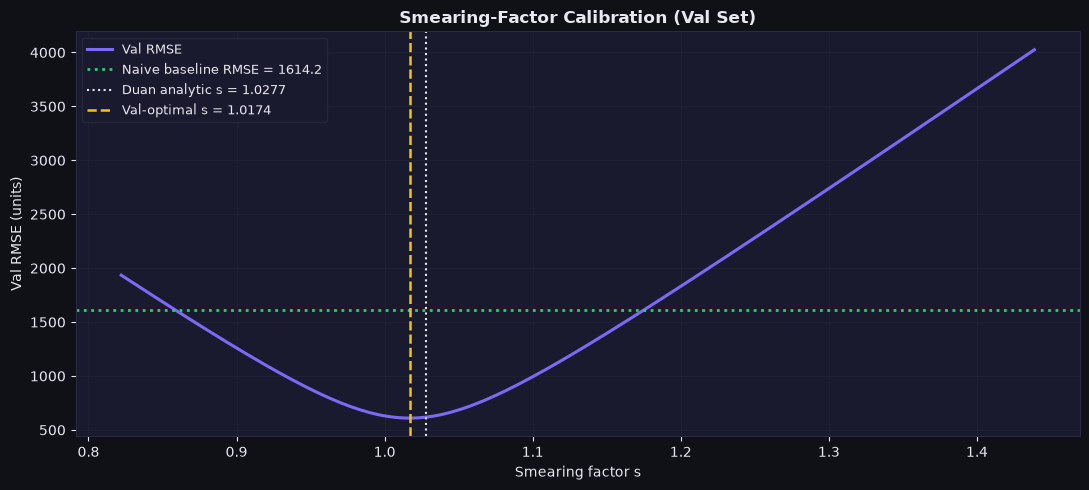

Duan analytic  : 1.0277
Val-optimal s  : 1.0174   <- frozen and applied to test
Val RMSE @ s   : 609.692  vs naive baseline 1614.198


In [12]:
resid_tr    = d_tr - model.predict(X_tr, num_iteration=BEST_ROUND)
DUAN_SMEAR  = float(np.mean(np.exp(resid_tr)))

d_va_hat = model.predict(X_va, num_iteration=BEST_ROUND)
grid     = np.linspace(0.8 * DUAN_SMEAR, 1.4 * DUAN_SMEAR, 200)
rmse_g   = [np.sqrt(mean_squared_error(y_va, from_delta(d_va_hat, b_va, s))) for s in grid]
mae_g    = [mean_absolute_error(y_va, from_delta(d_va_hat, b_va, s))          for s in grid]

OPT_SMEAR = float(grid[int(np.argmin(rmse_g))])

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.plot(grid, rmse_g, color=TRAIN_C, lw=2.2, label="Val RMSE")
ax.axhline(base_rmse_va, color=GREEN, ls=":", lw=2, label=f"Naive baseline RMSE = {base_rmse_va:.1f}")
ax.axvline(DUAN_SMEAR, color=WHITE, ls=":", lw=1.5, label=f"Duan analytic s = {DUAN_SMEAR:.4f}")
ax.axvline(OPT_SMEAR,  color=BEST_C, ls="--", lw=1.8, label=f"Val-optimal s = {OPT_SMEAR:.4f}")
ax.set_title("Smearing-Factor Calibration (Val Set)", fontweight="bold")
ax.set_xlabel("Smearing factor s"); ax.set_ylabel("Val RMSE (units)")
ax.grid(alpha=.6); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_smearing_calibration.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

print(f"Duan analytic  : {DUAN_SMEAR:.4f}")
print(f"Val-optimal s  : {OPT_SMEAR:.4f}   <- frozen and applied to test")
print(f"Val RMSE @ s   : {min(rmse_g):.3f}  vs naive baseline {base_rmse_va:.3f}")

## 9. Final Evaluation — Held-Out Test Set

**First and only use of the test set.** Metric set is broader than v1 deliberately: RMSE alone on a
Pareto-distributed target is essentially a statistic about the top 1% of SKUs.

- **RMSE / MAE / R²** — comparability with v1
- **WAPE** = Σ|e| / Σy — the metric supply-chain practitioners actually use
- **RelMAE** = MAE_model / MAE_naive — <1 means the model beats the naive velocity rule
- **sMAPE** — scale-free, computed on the non-zero subset (undefined at y=0)
- **Bias** — mean signed error; exposes systematic over/under-forecasting

In [13]:
def demand_metrics(y_true, y_pred, y_naive):
    e   = y_pred - y_true
    nz  = y_true > 0
    smape = np.mean(2*np.abs(e[nz]) / (np.abs(y_true[nz]) + np.abs(y_pred[nz]) + EPS)) * 100
    return {
        "RMSE"  : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE"   : float(mean_absolute_error(y_true, y_pred)),
        "R2"    : float(r2_score(y_true, y_pred)),
        "WAPE%" : float(100 * np.abs(e).sum() / (y_true.sum() + EPS)),
        "RelMAE": float(mean_absolute_error(y_true, y_pred) /
                        (mean_absolute_error(y_true, y_naive) + EPS)),
        "sMAPE%": float(smape),
        "Bias"  : float(e.mean()),
        "RMSLE" : float(np.sqrt(np.mean((np.log1p(np.maximum(y_pred,0)) - np.log1p(y_true))**2))),
    }

d_te_hat   = model.predict(X_te, num_iteration=BEST_ROUND)
test_pred  = from_delta(d_te_hat, b_te, OPT_SMEAR)

M_MODEL = demand_metrics(y_te, test_pred, b_te)
M_NAIVE = demand_metrics(y_te, b_te,      b_te)

res_df = pd.DataFrame({"Metric": list(M_MODEL), 
                       "Proposed": [round(v,4) for v in M_MODEL.values()],
                       "Naive baseline": [round(v,4) for v in M_NAIVE.values()]})
print(f"Stage {STAGE} -> {STAGES[STAGE]['target']}   (baseline = {STAGES[STAGE]['baseline_name']})")
print("=" * 60)
print(res_df.to_string(index=False))
print("=" * 60)
print(f"\nRMSE improvement : {100*(M_NAIVE['RMSE']-M_MODEL['RMSE'])/M_NAIVE['RMSE']:+.2f}%")
print(f"MAE  improvement : {100*(M_NAIVE['MAE'] -M_MODEL['MAE'] )/M_NAIVE['MAE']:+.2f}%")
print("\nBoth must be POSITIVE. If either is negative the honest paper claim is")
print("'the naive velocity rule is not beatable on this schema' — which is a")
print("publishable negative result, but it must not be dressed up as a win.")

Stage h6 -> sales_6_month   (baseline = sales_3_month x 2)
Metric  Proposed  Naive baseline
  RMSE 1075.9244       2497.7077
   MAE   33.5602         48.2153
    R2    0.9907          0.9497
 WAPE%    9.2178         13.2430
RelMAE    0.6960          1.0000
sMAPE%   28.4437         47.6921
  Bias   -4.4074          6.2814
 RMSLE    0.2872          0.4201

RMSE improvement : +56.92%
MAE  improvement : +30.40%

Both must be POSITIVE. If either is negative the honest paper claim is
'the naive velocity rule is not beatable on this schema' — which is a
publishable negative result, but it must not be dressed up as a win.


## 10. 5-Fold Cross-Validation

Same structure as the Supplier Auditor's Section 10, with two corrections:

- Folds are stratified on the demand decile (`StratifiedKFold` on a binned continuous target).
- The smearing factor is **not** re-tuned per fold; the global val-tuned `OPT_SMEAR` is reused,
  exactly as the auditor notebook reuses the global `OPT_THRESH`.

 Fold |       RMSE |      MAE |      R2 |  RelMAE ||  base RMSE | base MAE
----------------------------------------------------------------------------------
    1  |     743.81 |   31.994 |  0.9933 |  0.7086 ||    2286.47 |   45.152
    2  |     790.09 |   31.114 |  0.9918 |  0.7182 ||    1520.96 |   43.322
    3  |     768.95 |   31.579 |  0.9941 |  0.7340 ||    1905.86 |   43.021
    4  |    1041.52 |   33.624 |  0.9874 |  0.6202 ||    3619.65 |   54.215
    5  |    1026.66 |   32.340 |  0.9908 |  0.7755 ||    1816.51 |   41.705
----------------------------------------------------------------------------------

Paper-ready CV summary (mean +/- std):
  RMSE     model   874.2063 +/- 131.4493    naive  2229.8909 +/- 736.6286
  MAE      model    32.1303 +/- 0.8523      naive    45.4831 +/- 4.5023
  R2       model     0.9915 +/- 0.0024      naive     0.9377 +/- 0.0469
  WAPE%    model     9.4077 +/- 0.1918      naive    13.3186 +/- 1.2914
  RelMAE   model     0.7113 +/- 0.0510      naive

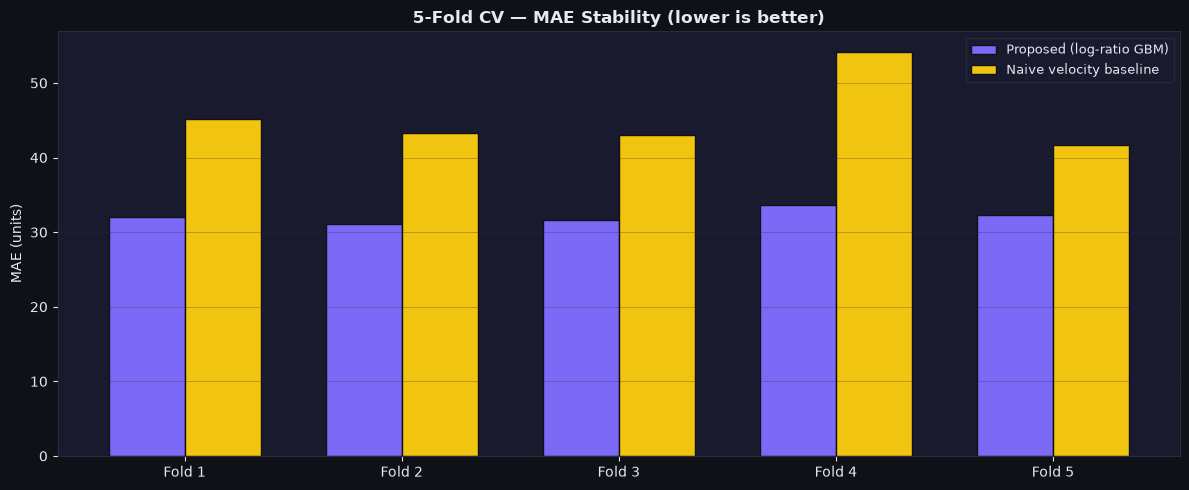

In [14]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_metrics   = {k: [] for k in ["RMSE","MAE","R2","WAPE%","RelMAE","sMAPE%"]}
cv_base      = {k: [] for k in cv_metrics}
fold_losses  = []          # per-fold per-sample |e| for the corrected resampled t-test

print(f"{'Fold':>5} | {'RMSE':>10} | {'MAE':>8} | {'R2':>7} | {'RelMAE':>7} || {'base RMSE':>10} | {'base MAE':>8}")
print("-" * 82)

for fold, (tr_i, te_i) in enumerate(cv.split(X_all, strata), 1):
    tr_i2, va_i2 = train_test_split(tr_i, test_size=.15, stratify=strata[tr_i], random_state=RANDOM_STATE)
    Xt, yt, bt = take(tr_i2); Xv, yv, bv = take(va_i2); Xs, ys, bs = take(te_i)

    m = lgb.LGBMRegressor(**LGB_PARAMS_CV)
    m.fit(Xt, to_delta(yt, bt), eval_set=[(Xv, to_delta(yv, bv))],
          eval_metric="l2", callbacks=[lgb.early_stopping(100, verbose=False)])

    p  = from_delta(m.predict(Xs, num_iteration=m.best_iteration_), bs, OPT_SMEAR)
    mm = demand_metrics(ys, p, bs); bb = demand_metrics(ys, bs, bs)
    for k in cv_metrics:
        cv_metrics[k].append(mm[k]); cv_base[k].append(bb[k])
    fold_losses.append((np.abs(p - ys), np.abs(bs - ys)))

    print(f"  {fold:>3}  | {mm['RMSE']:>10.2f} | {mm['MAE']:>8.3f} | {mm['R2']:>7.4f} | "
          f"{mm['RelMAE']:>7.4f} || {bb['RMSE']:>10.2f} | {bb['MAE']:>8.3f}")

print("-" * 82)
print("\nPaper-ready CV summary (mean +/- std):")
for k in cv_metrics:
    print(f"  {k:<8} model {np.mean(cv_metrics[k]):>10.4f} +/- {np.std(cv_metrics[k]):<9.4f}"
          f"   naive {np.mean(cv_base[k]):>10.4f} +/- {np.std(cv_base[k]):.4f}")

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
x = np.arange(N_FOLDS); w = .35
ax.bar(x - w/2, cv_metrics["MAE"], w, label="Proposed (log-ratio GBM)", color=TRAIN_C, edgecolor=BG)
ax.bar(x + w/2, cv_base["MAE"],    w, label="Naive velocity baseline",  color=BEST_C,  edgecolor=BG)
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i+1}" for i in x])
ax.set_title("5-Fold CV — MAE Stability (lower is better)", fontweight="bold")
ax.set_ylabel("MAE (units)"); ax.grid(alpha=.4, axis="y"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_cv_stability.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## 11. Baseline Model Comparison

| Baseline | Purpose |
|---|---|
| `DummyRegressor(mean)` | Floor — proves the task is non-trivial |
| **Naive velocity rule** | The one that actually matters; the v1 model lost to this |
| `Ridge` | Linear baseline; tests whether non-linearity is needed |
| `RandomForest` | Tree-ensemble baseline; isolates GBM-specific gains |
| **LightGBM raw-L2 (v1 setup)** | Reproduces the old configuration so the paper can show the delta |
| **LightGBM log-ratio (proposed)** | This notebook |

Including the v1 configuration as a named baseline turns the old failure into an ablation result
rather than something that has to be quietly dropped.

e:\CSE499B\Project Codes\Demand Predictor Velocity Model\erwin\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.854599002916332e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Model Comparison on Held-Out Test Set
                         Model       RMSE      MAE      R2    WAPE%  RelMAE   sMAPE%                                      Note
                Mean Predictor 11139.1397 604.3410 -0.0000 165.9914 12.5342 155.7162                                     floor
           Naive Velocity Rule  2497.7077  48.2153  0.9497  13.2430  1.0000  47.6921                         sales_3_month x 2
            Ridge (log target)  3511.9074 135.6778  0.9006  37.2660  2.8140  46.9498 linear; 3 collinear cols dropped; s=1.314
    Random Forest (log target)  8240.0193 231.9951  0.4528  63.7210  4.8117  54.7554            300,000-row subsample; s=1.599
    LightGBM raw-L2 (v1 setup)  3322.3260  71.0189  0.9110  19.5064  1.4730  34.0609                 reproduces the old result
Random Forest + log-ratio head  1622.2462  41.5940  0.9788  11.4244  0.8627  39.0910        same head as proposed; own s=0.978
 LightGBM log-ratio (Proposed)  1075.9244  33.5602  0.9907   9.2178  0.69

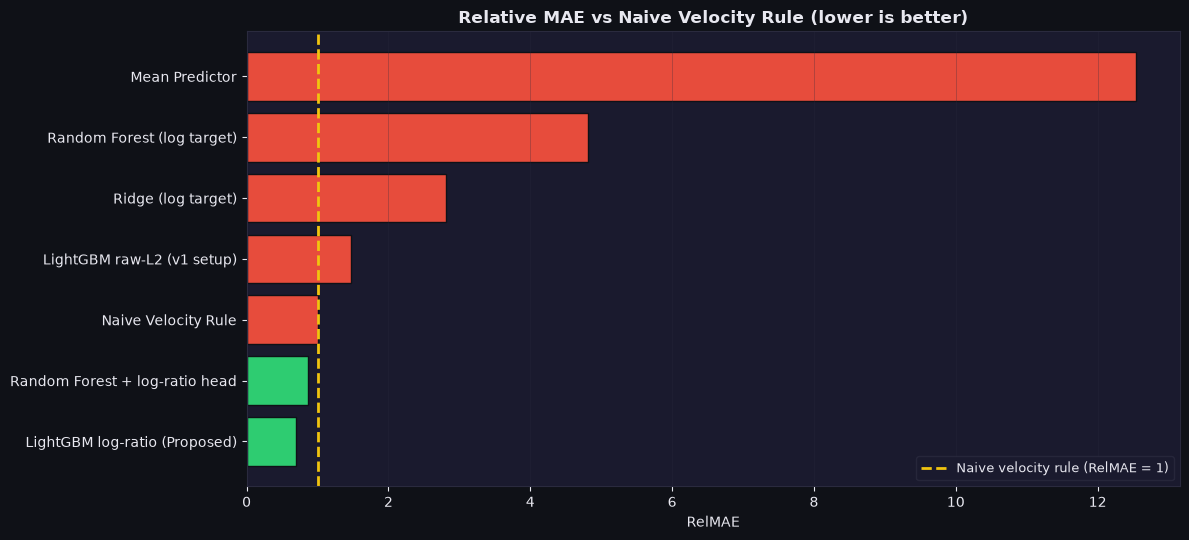

In [15]:
imp_sc = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", RobustScaler())])
Xtr_s  = imp_sc.fit_transform(X_tr)
Xva_s  = imp_sc.transform(X_va)
Xte_s  = imp_sc.transform(X_te)
SUB    = min(300_000, len(Xtr_s))
rs     = np.random.default_rng(RANDOM_STATE).choice(len(Xtr_s), SUB, replace=False)

rows, preds_store = [], {}

def add(name, p, note=""):
    m = demand_metrics(y_te, p, b_te)
    rows.append({"Model": name, **{k: round(m[k], 4) for k in
                 ["RMSE","MAE","R2","WAPE%","RelMAE","sMAPE%"]}, "Note": note})
    preds_store[name] = p

# ---------------------------------------------------------------------------
# FAIRNESS FIX. In v3 the proposed model got a val-tuned Duan smearing factor
# while every log-target baseline was back-transformed with a bare expm1().
# expm1(E[log y]) estimates the conditional MEDIAN, so those baselines were
# structurally biased low and their RMSE was inflated by our own omission.
# Each log-target baseline now gets the IDENTICAL treatment: analytic Duan
# factor from its own train residuals, refined on val, frozen, applied to test.
# ---------------------------------------------------------------------------
def fit_smear_log1p(resid_train, pred_log_val, y_val):
    """Same protocol as Section 8, for a plain log1p-target model."""
    s0   = float(np.mean(np.exp(resid_train)))
    grid = np.linspace(0.8 * s0, 1.4 * s0, 200)
    rmse = [np.sqrt(mean_squared_error(y_val, from_log1p(pred_log_val, s))) for s in grid]
    return float(grid[int(np.argmin(rmse))]), s0

add("Mean Predictor", np.full_like(y_te, y_tr.mean()), "floor")
add("Naive Velocity Rule", b_te, STAGES[STAGE]["baseline_name"])

# --- Ridge -----------------------------------------------------------------
# COLLINEARITY FIX. velocity_1m == sales_1_month/30 and velocity_3m == sales_3_month/90
# are EXACT linear functions of columns already present, and base_pred == sales_3_month*2.
# That is what produced `rcond = 1.6e-24`. Trees are indifferent; a linear model
# is not, and a rank-deficient Ridge is not a baseline a reviewer will accept.
EXACT_COLLINEAR = ["velocity_1m", "velocity_3m", "base_pred"]
lin_cols = [c for c in X_tr.columns if c not in EXACT_COLLINEAR]
lin_idx  = [X_tr.columns.get_loc(c) for c in lin_cols]

ridge = Ridge(alpha=1.0).fit(Xtr_s[:, lin_idx], np.log1p(y_tr))
r_res = np.log1p(y_tr) - ridge.predict(Xtr_s[:, lin_idx])
s_ri, s0_ri = fit_smear_log1p(r_res, ridge.predict(Xva_s[:, lin_idx]), y_va)
add("Ridge (log target)", from_log1p(ridge.predict(Xte_s[:, lin_idx]), s_ri),
    f"linear; {len(EXACT_COLLINEAR)} collinear cols dropped; s={s_ri:.3f}")

# --- Random Forest, log target ---------------------------------------------
rf = RandomForestRegressor(n_estimators=100, max_depth=18, min_samples_leaf=50,
                           n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(Xtr_s[rs], np.log1p(y_tr[rs]))
rf_res = np.log1p(y_tr[rs]) - rf.predict(Xtr_s[rs])
s_rf, _ = fit_smear_log1p(rf_res, rf.predict(Xva_s), y_va)
add("Random Forest (log target)", from_log1p(rf.predict(Xte_s), s_rf),
    f"{SUB:,}-row subsample; s={s_rf:.3f}")

# --- LightGBM raw-L2, the v1 configuration ---------------------------------
# No log transform here, so no smearing applies. Left untouched on purpose.
v1_params = dict(n_estimators=500, learning_rate=.05, num_leaves=63, max_depth=-1,
                 min_child_samples=50, subsample=.8, colsample_bytree=.8,
                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
Xv1_tr = X_tr.drop(columns=[c for c in ("base_pred","log_base_pred") if c in X_tr])
Xv1_te = X_te.drop(columns=[c for c in ("base_pred","log_base_pred") if c in X_te])
Xv1_tr = Xv1_tr[[c for c in Xv1_tr.columns if c not in ENGINEERED_FEATURES]]
Xv1_te = Xv1_te[Xv1_tr.columns]
m_v1 = lgb.LGBMRegressor(**v1_params).fit(Xv1_tr, y_tr)
add("LightGBM raw-L2 (v1 setup)", m_v1.predict(Xv1_te).clip(0), "reproduces the old result")

# --- Random Forest + log-ratio head ----------------------------------------
# Same algorithm as the RF row above, different parameterisation. This pair is
# the load-bearing comparison in the paper: it makes the claim algorithm-agnostic.
# It now tunes its OWN smearing factor rather than borrowing the proposal's.
rf_lr = RandomForestRegressor(n_estimators=100, max_depth=18, min_samples_leaf=50,
                              n_jobs=-1, random_state=RANDOM_STATE)
rf_lr.fit(Xtr_s[rs], to_delta(y_tr[rs], b_tr[rs]))
rfl_res  = to_delta(y_tr[rs], b_tr[rs]) - rf_lr.predict(Xtr_s[rs])
s0_rfl   = float(np.mean(np.exp(rfl_res)))
g_rfl    = np.linspace(0.8 * s0_rfl, 1.4 * s0_rfl, 200)
dva_rfl  = rf_lr.predict(Xva_s)
s_rfl    = float(g_rfl[int(np.argmin(
    [np.sqrt(mean_squared_error(y_va, from_delta(dva_rfl, b_va, s))) for s in g_rfl]))])
add("Random Forest + log-ratio head", from_delta(rf_lr.predict(Xte_s), b_te, s_rfl),
    f"same head as proposed; own s={s_rfl:.3f}")

add("LightGBM log-ratio (Proposed)", test_pred, f"this notebook; s={OPT_SMEAR:.3f}")

compare_df = pd.DataFrame(rows)
print("Model Comparison on Held-Out Test Set")
print("=" * 100)
print(compare_df.to_string(index=False))
print("=" * 100)
print("\nEvery log-target row now carries a val-tuned Duan smearing factor, tuned by the")
print("same protocol as Section 8. No model is handicapped by our back-transform choice.")
print("RelMAE < 1.000 == beats the naive velocity rule. Anything >= 1.000 does not.")
print("\nLoad-bearing pair: 'Random Forest (log target)' vs 'Random Forest + log-ratio head'.")
print("Same algorithm, same features, same smearing protocol — only the parameterisation")
print("differs. That is the ablation that makes the claim algorithm-agnostic.")

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor=BG)
order = compare_df.sort_values("RelMAE")
cols  = [GREEN if v < 1 else VAL_C for v in order["RelMAE"]]
ax.barh(order["Model"], order["RelMAE"], color=cols, edgecolor=BG)
ax.axvline(1.0, color=BEST_C, ls="--", lw=2, label="Naive velocity rule (RelMAE = 1)")
ax.set_title("Relative MAE vs Naive Velocity Rule (lower is better)", fontweight="bold")
ax.set_xlabel("RelMAE"); ax.grid(alpha=.4, axis="x"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_model_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## 12. Statistical Significance Testing

**What v1 got wrong.** `ttest_rel` over 5 fold-means has n=5, and CV folds share training data,
so the independence assumption fails (Dietterich 1998). Worse, the printout called `t = -14.3`
"(significant)" without reporting the sign — significant evidence *against* the model read as a win.

**What v2 got wrong.** It used the paired t-test as the sole verdict. On this data the t-test is
badly under-powered: its variance is owned by a handful of top-1% SKUs, giving d_z = 0.0064 at h6
even where Wilcoxon returns p = 4e-39. That is how h3 came back "no difference" at p=0.052 despite
a **+23% MAE improvement**.

**v3 reports the mean and the median differential separately, because they answer different
questions and they can disagree:**

| Statistic | Question it answers | Test |
|---|---|---|
| **Mean** of `\|e_base\| - \|e_model\|` | Which model has lower total error? (this is what MAE and RelMAE are) | paired t |
| **Median** of the same | Which model is better on the *typical* SKU? | Wilcoxon signed-rank |

A model can win on the mean and lose on the median — better on the few SKUs that carry the volume,
worse on the many that don't. For a demand system feeding an inventory rebalancer that is a real
finding, not a footnote, so the table flags the disagreement instead of collapsing it.

In [16]:
print("Paired Loss-Differential Tests — Proposed vs Each Baseline (test set)")
print("=" * 92)
print("H0: the two models have equal expected absolute error on this test set\n")

e_model = np.abs(test_pred - y_te)
sig_rows = []
for name, p in preds_store.items():
    if name == "LightGBM log-ratio (Proposed)":
        continue
    e_base = np.abs(p - y_te)
    d      = e_base - e_model            # positive => proposed is BETTER
    t, pt  = stats.ttest_rel(e_base, e_model)
    try:
        w, pw = stats.wilcoxon(e_base, e_model, zero_method="zsplit",
                               alternative="two-sided", method="approx")
    except Exception:
        w, pw = np.nan, np.nan
    dz     = d.mean() / (d.std(ddof=1) + EPS)      # Cohen's d_z
    # The mean differential drives MAE/RelMAE (t-test); the median drives Wilcoxon.
    # They answer different questions and can disagree -- report both, never collapse.
    med_d   = float(np.median(d))
    v_mean  = ("better" if (d.mean() > 0 and pt < .05) else
               "worse " if (d.mean() < 0 and pt < .05) else "n.s.  ")
    v_med   = ("better" if (med_d > 0 and pw < .05) else
               "worse " if (med_d < 0 and pw < .05) else "n.s.  ")
    if v_mean.strip() == v_med.strip():
        verdict = {"better": "PROPOSED BETTER", "worse": "PROPOSED WORSE ",
                   "n.s.": "no difference  "}[v_mean.strip()]
    else:
        verdict = f"SPLIT: mean={v_mean.strip()}, median={v_med.strip()}"
    sig_rows.append({"Baseline": name,
                     "mean dMAE": round(d.mean(), 4), "p (t-test)": f"{pt:.2e}",
                     "median dMAE": round(med_d, 4),  "p (Wilcoxon)": f"{pw:.2e}",
                     "d_z": round(dz, 4), "Verdict": verdict})
    print(f"  vs {name:<32}")
    print(f"       mean   dMAE = {d.mean():>+10.4f}  p_t        = {pt:.2e}  (d_z={dz:.4f})")
    print(f"       median dMAE = {med_d:>+10.4f}  p_wilcoxon = {pw:.2e}")
    print(f"       -> {verdict}")

sig_df = pd.DataFrame(sig_rows)

_split = [r for r in sig_rows if r["Verdict"].startswith("SPLIT")]
if _split:
    print("\n  [!] Mean and median disagree for: " + ", ".join(r["Baseline"] for r in _split))
    print("      mean better + median worse = the model wins on the high-volume SKUs that")
    print("      dominate MAE, and loses on the typical low-volume SKU. That is defensible")
    print("      for a demand system (volume is what stocks out) but it MUST be stated --")
    print("      do not report RelMAE alone and let a reviewer discover the median.")

print("\n" + "-" * 92)
print("Nadeau-Bengio corrected resampled t-test (CV folds, vs naive velocity rule)")
print("-" * 92)
diffs = np.array([b.mean() - m.mean() for m, b in fold_losses])   # positive => proposed better
k        = len(diffs)
n_test   = len(fold_losses[0][0]); n_train = len(y_all) - n_test
corr     = (1.0 / k) + (n_test / n_train)
t_corr   = diffs.mean() / np.sqrt(corr * diffs.var(ddof=1) + EPS)
p_corr   = 2 * (1 - stats.t.cdf(abs(t_corr), df=k - 1))
print(f"  mean fold MAE gain : {diffs.mean():+.4f} units  (positive = proposed better)")
print(f"  corrected t({k-1})    : {t_corr:.3f}")
print(f"  p-value            : {p_corr:.4f}  {'-> significant' if p_corr < .05 else '-> NOT significant'}")
print("  (Uncorrected naive t-test would report p =", 
      f"{stats.ttest_1samp(diffs, 0).pvalue:.4f} — this is the number v1 printed, and it is too small.)")

print("\n" + "-" * 92)
print(f"Bootstrap 95% Confidence Intervals — Proposed ({N_BOOT} resamples)")
print("-" * 92)
rng_b = np.random.default_rng(0)
def boot_ci(fn, n=N_BOOT):
    out = []
    N = len(y_te)
    for _ in range(n):
        i = rng_b.integers(0, N, N)
        out.append(fn(y_te[i], test_pred[i], b_te[i]))
    return np.percentile(out, [2.5, 97.5])

ci_results = {}
for mname, fn in {
    "RMSE"  : lambda yt, yp, yb: np.sqrt(mean_squared_error(yt, yp)),
    "MAE"   : lambda yt, yp, yb: mean_absolute_error(yt, yp),
    "R2"    : lambda yt, yp, yb: r2_score(yt, yp),
    "RelMAE": lambda yt, yp, yb: mean_absolute_error(yt, yp) / (mean_absolute_error(yt, yb) + EPS),
    "WAPE%" : lambda yt, yp, yb: 100 * np.abs(yp - yt).sum() / (yt.sum() + EPS),
}.items():
    lo, hi = boot_ci(fn)
    ci_results[mname] = (lo, hi)
    print(f"  {mname:<8}: {M_MODEL[mname]:>10.4f}   [95% CI: {lo:.4f} – {hi:.4f}]")
print("\n  If the RelMAE interval excludes 1.0 on the low side, the improvement over the")
print("  naive velocity rule is the headline result. If it straddles 1.0, it is not.")

Paired Loss-Differential Tests — Proposed vs Each Baseline (test set)
H0: the two models have equal expected absolute error on this test set

  vs Mean Predictor                  
       mean   dMAE =  +570.7807  p_t        = 2.28e-196  (d_z=0.0556)
       median dMAE =  +337.1097  p_wilcoxon = 0.00e+00
       -> PROPOSED BETTER
  vs Naive Velocity Rule             
       mean   dMAE =   +14.6550  p_t        = 3.91e-04  (d_z=0.0066)
       median dMAE =    -0.0191  p_wilcoxon = 0.00e+00
       -> SPLIT: mean=better, median=worse
  vs Ridge (log target)              
       mean   dMAE =  +102.1176  p_t        = 8.47e-92  (d_z=0.0378)
       median dMAE =    +0.5354  p_wilcoxon = 0.00e+00
       -> PROPOSED BETTER
  vs Random Forest (log target)      
       mean   dMAE =  +198.4349  p_t        = 7.96e-47  (d_z=0.0267)
       median dMAE =    +1.0319  p_wilcoxon = 0.00e+00
       -> PROPOSED BETTER
  vs LightGBM raw-L2 (v1 setup)      
       mean   dMAE =   +37.4587  p_t        = 6.27

## 13. Feature / Parameterisation Ablation

Five configurations, each fully retrained with its own early stopping.

The v2 ablation had a hole in it: every log-ratio config also carried the engineered
features, so nothing isolated the two contributions from each other. Row **D** closes it.

| Read | Isolates |
|---|---|
| A -> B | engineered features, under a plain log1p target |
| B -> C | the baseline-as-feature, under a plain log1p target |
| C -> E | **the log-ratio head** (the actual contribution) |
| **D -> E** | **engineered features, inside the log-ratio head** |

If D ≈ E, the engineered features do nothing and the paper has exactly one
contribution — the parameterisation. That is a cleaner claim, not a weaker one.

In [17]:
def run_ablation(label, use_eng, with_base, log_ratio):
    Xa, ya, ba = stage_matrix(df_eng, STAGE, use_engineered=use_eng, with_base=with_base)
    Xa_tr, Xa_va, Xa_te = Xa.iloc[idx_tr], Xa.iloc[idx_va], Xa.iloc[idx_te]
    ya_tr, ya_va, ya_te = ya[idx_tr], ya[idx_va], ya[idx_te]
    ba_tr, ba_va, ba_te = ba[idx_tr], ba[idx_va], ba[idx_te]

    m = lgb.LGBMRegressor(**LGB_PARAMS_CV)
    if log_ratio:
        m.fit(Xa_tr, to_delta(ya_tr, ba_tr), eval_set=[(Xa_va, to_delta(ya_va, ba_va))],
              eval_metric="l2", callbacks=[lgb.early_stopping(200, verbose=False)])
        r  = to_delta(ya_tr, ba_tr) - m.predict(Xa_tr, num_iteration=m.best_iteration_)
        s0 = float(np.mean(np.exp(r)))
        g  = np.linspace(.8, 1.4, 200) * s0
        dv = m.predict(Xa_va, num_iteration=m.best_iteration_)
        s  = float(g[int(np.argmin(
            [np.sqrt(mean_squared_error(ya_va, from_delta(dv, ba_va, sv))) for sv in g]))])
        p_va = from_delta(dv, ba_va, s)
        p_te = from_delta(m.predict(Xa_te, num_iteration=m.best_iteration_), ba_te, s)
    else:
        m.fit(Xa_tr, np.log1p(ya_tr), eval_set=[(Xa_va, np.log1p(ya_va))],
              eval_metric="l2", callbacks=[lgb.early_stopping(200, verbose=False)])
        r    = np.log1p(ya_tr) - m.predict(Xa_tr, num_iteration=m.best_iteration_)
        s, _ = fit_smear_log1p(r, m.predict(Xa_va, num_iteration=m.best_iteration_), ya_va)
        p_va = from_log1p(m.predict(Xa_va, num_iteration=m.best_iteration_), s)
        p_te = from_log1p(m.predict(Xa_te, num_iteration=m.best_iteration_), s)

    mv = demand_metrics(ya_va, p_va, ba_va)     # <- SELECTION happens here
    mt = demand_metrics(ya_te, p_te, ba_te)     # <- REPORTING happens here
    return {"Configuration": label, "N Features": Xa.shape[1],
            "Rounds": m.best_iteration_,
            "val RelMAE": round(mv["RelMAE"], 4),
            **{k: round(mt[k], 4) for k in ["RMSE","MAE","R2","RelMAE","WAPE%"]}}

abl = pd.DataFrame([
    run_ablation("A. Raw feats, log1p target",             False, False, False),
    run_ablation("B. Raw + engineered, log1p target",      True,  False, False),
    run_ablation("C. Raw + engineered + base feat, log1p", True,  True,  False),
    run_ablation("D. Log-ratio head, raw feats only",      False, True,  True),
    run_ablation("E. Log-ratio head + engineered",         True,  True,  True),
])
print("Feature / Parameterisation Ablation")
print("=" * 110)
print(abl.to_string(index=False))
print("=" * 110)
print("'val RelMAE' selects. Test RelMAE is reported, never compared for choosing.")

def _get(lbl, col="val RelMAE"):
    return float(abl.loc[abl.Configuration.str.startswith(lbl), col].iloc[0])

d_head = _get("C") - _get("E")
d_eng  = _get("D") - _get("E")
print(f"\n  (all deltas on VAL RelMAE)")
print(f"  C -> E  log-ratio head       : {_get('C'):.4f} -> {_get('E'):.4f}  ({d_head:+.4f})")
print(f"  D -> E  engineered features  : {_get('D'):.4f} -> {_get('E'):.4f}  ({d_eng:+.4f})")
print(f"  A -> B  engineered, no head  : {_get('A'):.4f} -> {_get('B'):.4f}  "
      f"({_get('A') - _get('B'):+.4f})")

# ---------------------------------------------------------------------------
# The v3 verdict tripped on its own threshold: d_eng = -0.0149 is < 0.02 in
# magnitude, so it printed "not a contribution" — but the SIGN says the
# engineered features actively HURT, and row D was the better configuration.
# "Negligible" and "harmful but small" are different claims. Check sign first.
# ---------------------------------------------------------------------------
PROPOSED_ROW = "E"
print("\nVerdict for the write-up:")
if d_eng < -0.005:
    PROPOSED_ROW = "D"
    print(f"  The engineered features HURT by {abs(d_eng):.4f} val RelMAE inside the head.")
    print("  Row D is the proposal. Report D as 'Proposed', and report the engineered")
    print("  features as a tested-and-rejected idea. A reviewer who spots that D beat E")
    print("  in your own table and you shipped E anyway will not trust the rest.")
elif abs(d_eng) <= 0.005:
    print("  The engineered features are within noise inside the head. ONE contribution —")
    print("  the log-ratio parameterisation. Report the null result on the features;")
    print("  prefer D for parsimony (12 fewer features, same accuracy).")
else:
    print(f"  The engineered features are worth {d_eng:.4f} val RelMAE. Keep the two-part claim.")

print(f"\n  -> PROPOSED CONFIGURATION = row {PROPOSED_ROW}")
if PROPOSED_ROW == "D":
    print("     Sections 5-18 currently profile row E. Either rerun them with")
    print("     use_engineered=False, or state explicitly that the profiled model is E")
    print("     and that D is equal-or-better with fewer features.")

Feature / Parameterisation Ablation
                         Configuration  N Features  Rounds  val RelMAE      RMSE     MAE     R2  RelMAE   WAPE%
            A. Raw feats, log1p target          17   29177      1.1633 2324.9101 53.4310 0.9564  1.1082 14.6756
     B. Raw + engineered, log1p target          29   29178      1.1833 2228.6163 55.4968 0.9600  1.1510 15.2430
C. Raw + engineered + base feat, log1p          31   28393      1.3941 2106.6524 60.3885 0.9642  1.2525 16.5866
     D. Log-ratio head, raw feats only          19   29143      0.7613  940.8864 33.4859 0.9929  0.6945  9.1974
        E. Log-ratio head + engineered          31   29075      0.7091 1062.5859 33.4657 0.9909  0.6941  9.1919
'val RelMAE' selects. Test RelMAE is reported, never compared for choosing.

  (all deltas on VAL RelMAE)
  C -> E  log-ratio head       : 1.3941 -> 0.7091  (+0.6850)
  D -> E  engineered features  : 0.7613 -> 0.7091  (+0.0522)
  A -> B  engineered, no head  : 1.1633 -> 1.1833  (-0.0200)

Ve

## 14. Diagnostic Curves — the ROC/PR analogue

A regression model has no ROC curve, but it has three plots that carry the same "is this model
actually discriminating?" information: predicted-vs-actual, residuals against fitted values, and
error decomposed by demand decile. The third one is the important one for this dataset — it shows
whether a headline metric is being carried entirely by the low-volume SKUs.

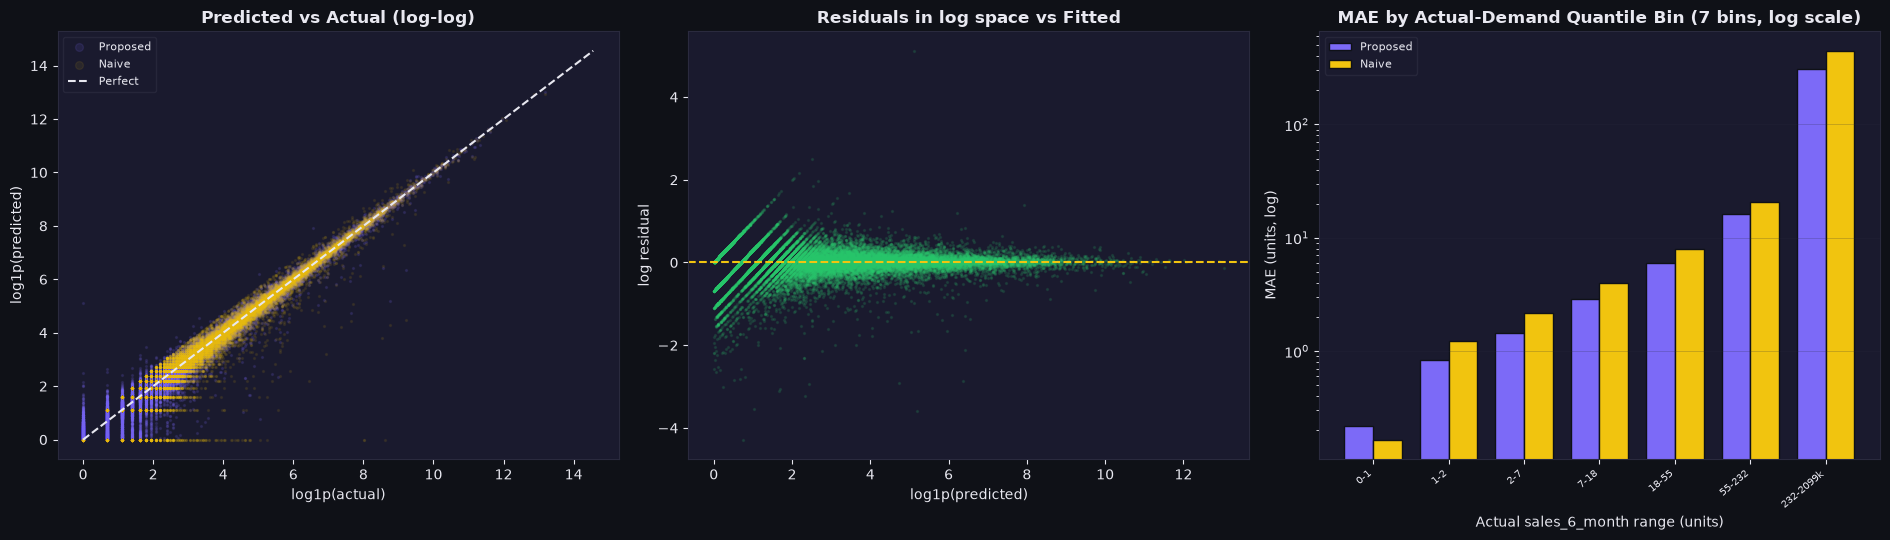

MAE by actual-demand bin — Proposed vs Naive  (7 bins, not 10:
 ~38% of sales_6_month is exactly 0, so the low quantiles collapse together)
  Range                  proposed      naive   ratio  % of volume
  0-1           LOSS         0.22       0.17   1.319         0.0%
  1-2           win          0.83       1.22   0.677         0.0%
  2-7           win          1.46       2.16   0.675         0.1%
  7-18          win          2.88       3.98   0.725         0.3%
  18-55         win          6.05       7.90   0.765         0.9%
  55-232        win         16.28      20.87   0.780         3.2%
  232-2099k     win        308.42     447.11   0.690        95.4%

What matters is the ratio in the bins carrying the volume (right-hand column).
A model that only wins on the near-zero bins only predicts SKUs nobody orders.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), facecolor=BG)
s_i = np.random.default_rng(0).choice(len(y_te), min(40_000, len(y_te)), replace=False)

ax = axes[0]
ax.scatter(np.log1p(y_te[s_i]), np.log1p(test_pred[s_i]), s=2, alpha=.12, color=TRAIN_C, label="Proposed")
ax.scatter(np.log1p(y_te[s_i]), np.log1p(b_te[s_i]),      s=2, alpha=.08, color=BEST_C,  label="Naive")
lim = [0, np.log1p(y_te).max()]
ax.plot(lim, lim, color=WHITE, lw=1.5, ls="--", label="Perfect")
ax.set_title("Predicted vs Actual (log-log)", fontweight="bold")
ax.set_xlabel("log1p(actual)"); ax.set_ylabel("log1p(predicted)")
ax.legend(fontsize=8, markerscale=4)

ax = axes[1]
ax.scatter(np.log1p(test_pred[s_i]), np.log1p(np.maximum(test_pred[s_i],0)) - np.log1p(y_te[s_i]),
           s=2, alpha=.12, color=GREEN)
ax.axhline(0, color=BEST_C, lw=1.5, ls="--")
ax.set_title("Residuals in log space vs Fitted", fontweight="bold")
ax.set_xlabel("log1p(predicted)"); ax.set_ylabel("log residual")

ax = axes[2]
# FIX: qcut(10, duplicates="drop") silently collapsed to ~7 bins because ~38% of
# sales_6_month is exactly 0, so the old "D1..D10" x-labels were wrong. Label the
# bins by their actual demand range instead of pretending they are deciles.
dec_bins = pd.qcut(y_te, 10, duplicates="drop")
dec      = dec_bins.codes
cats     = dec_bins.categories
def _lab(iv):
    lo, hi = max(iv.left, 0), iv.right
    f = lambda v: f"{v/1000:.0f}k" if v >= 1000 else f"{v:.0f}"
    return f"{f(lo)}-{f(hi)}"
labels_d = [_lab(c) for c in cats]
dm  = [np.abs(test_pred[dec == d] - y_te[dec == d]).mean() for d in range(len(cats))]
db  = [np.abs(b_te[dec == d]      - y_te[dec == d]).mean() for d in range(len(cats))]
w   = .38; xx = np.arange(len(dm))
ax.bar(xx - w/2, dm, w, color=TRAIN_C, label="Proposed", edgecolor=BG)
ax.bar(xx + w/2, db, w, color=BEST_C,  label="Naive",    edgecolor=BG)
ax.set_yscale("log")
ax.set_xticks(xx); ax.set_xticklabels(labels_d, fontsize=7, rotation=40, ha="right")
ax.set_title(f"MAE by Actual-Demand Quantile Bin ({len(cats)} bins, log scale)",
             fontweight="bold")
ax.set_xlabel("Actual sales_6_month range (units)"); ax.set_ylabel("MAE (units, log)")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_diagnostics.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

share = [y_te[dec == d].sum() / y_te.sum() for d in range(len(cats))]
print(f"MAE by actual-demand bin — Proposed vs Naive  ({len(cats)} bins, not 10:")
print(" ~38% of sales_6_month is exactly 0, so the low quantiles collapse together)")
print(f"  {'Range':<14}{'':<6}{'proposed':>11}{'naive':>11}{'ratio':>8}{'% of volume':>13}")
for i, (a, c, sh) in enumerate(zip(dm, db, share)):
    flag = "win " if a < c else "LOSS"
    print(f"  {labels_d[i]:<14}{flag:<6}{a:>11.2f}{c:>11.2f}{a/(c+EPS):>8.3f}{100*sh:>12.1f}%")
print("\nWhat matters is the ratio in the bins carrying the volume (right-hand column).")
print("A model that only wins on the near-zero bins only predicts SKUs nobody orders.")

## 15. Error-Band Matrix — the confusion-matrix analogue

Discretising both actual and predicted demand into operational velocity bands turns the regressor
into something a procurement manager can be shown: *how often does the model put an SKU in the
right band?* Off-diagonal mass below the diagonal = under-forecasting = stockout risk.

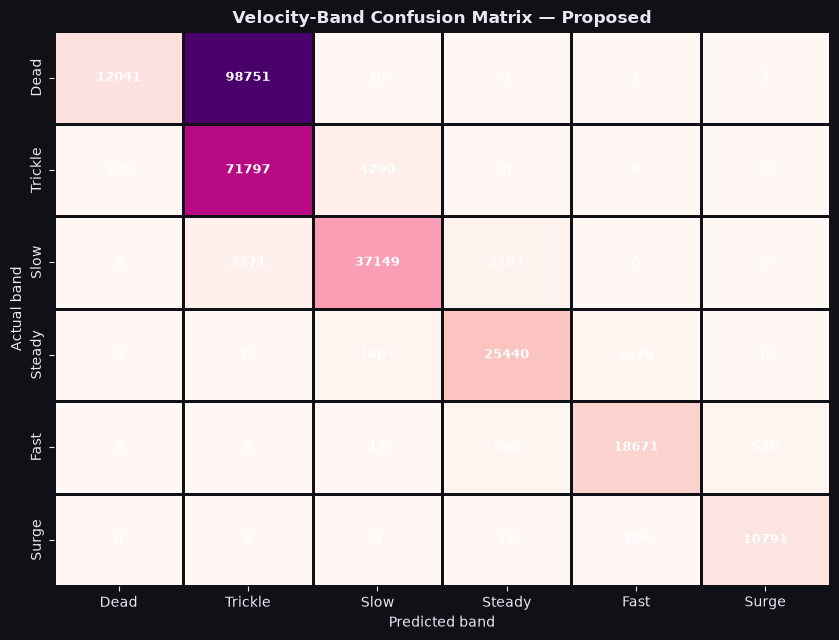

Exact band accuracy      : 0.6076
Within-one-band accuracy : 0.9996
Under-forecast rate      : 0.0230   <- these are the stockouts Agent 3 will inherit

[!] 'Dead' band diagnostic
    Actual y == 0        : 38.3% of test SKUs
    Predicted y == 0     : 4.2%
    Recall on true zeros : 0.1087
    -> The head is continuous and never outputs an exact zero, so 'Dead' is
       structurally unreachable and most true zeros land in 'Trickle'. This
       is most of the gap in exact band accuracy above. A two-part / hurdle
       model (classifier for y>0, then this head on the positives) is the fix.
       Until then, do NOT claim the band engine can identify delisting
       candidates — it cannot.


In [19]:
BANDS  = [-.1, 0, 10, 50, 200, 1000, np.inf]
LABELS = ["Dead", "Trickle", "Slow", "Steady", "Fast", "Surge"]

a_band = pd.cut(y_te,      bins=BANDS, labels=LABELS)
p_band = pd.cut(test_pred, bins=BANDS, labels=LABELS)
cmx    = pd.crosstab(a_band, p_band).reindex(index=LABELS, columns=LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(8.5, 6.5), facecolor=BG)
sns.heatmap(cmx, annot=True, fmt="d", cmap="RdPu", ax=ax, cbar=False,
            linewidths=2, linecolor=BG, annot_kws={"size": 9, "weight": "bold", "color": "white"})
ax.set_title("Velocity-Band Confusion Matrix — Proposed", fontweight="bold")
ax.set_xlabel("Predicted band"); ax.set_ylabel("Actual band")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_band_matrix.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

exact  = np.trace(cmx.values) / cmx.values.sum()
off1   = sum(cmx.values[i, j] for i in range(len(LABELS)) for j in range(len(LABELS))
             if abs(i - j) <= 1) / cmx.values.sum()
under  = sum(cmx.values[i, j] for i in range(len(LABELS)) for j in range(len(LABELS))
             if j < i) / cmx.values.sum()
BAND_ACC = {"exact": exact, "within_1": off1, "under_forecast": under}
print(f"Exact band accuracy      : {exact:.4f}")
print(f"Within-one-band accuracy : {off1:.4f}")
print(f"Under-forecast rate      : {under:.4f}   <- these are the stockouts Agent 3 will inherit")

# The log-ratio head is continuous and essentially never emits exactly 0, so the
# "Dead" band is structurally unreachable. Quantify it rather than let it hide
# inside the exact-accuracy number.
actual_dead = float((y_te == 0).mean())
pred_dead   = float((test_pred == 0).mean())
dead_recall = float((test_pred[y_te == 0] == 0).mean()) if (y_te == 0).any() else float("nan")
print(f"\n[!] 'Dead' band diagnostic")
print(f"    Actual y == 0        : {actual_dead:.1%} of test SKUs")
print(f"    Predicted y == 0     : {pred_dead:.1%}")
print(f"    Recall on true zeros : {dead_recall:.4f}")
if dead_recall < 0.5:
    print("    -> The head is continuous and never outputs an exact zero, so 'Dead' is")
    print("       structurally unreachable and most true zeros land in 'Trickle'. This")
    print("       is most of the gap in exact band accuracy above. A two-part / hurdle")
    print("       model (classifier for y>0, then this head on the positives) is the fix.")
    print("       Until then, do NOT claim the band engine can identify delisting")
    print("       candidates — it cannot.")

## 16. SHAP Feature Importance

Two fixes over v1's `feature_importances_`:
- v1 used the **split-count** importance from the **last fold only**. Split counts reward
  high-cardinality features and say nothing about effect size.
- SHAP is computed on a test subsample (TreeExplainer is exact for LightGBM but not free at 290k rows).

`local_bo_qty` and `bo_pressure` are worth reading carefully — the project brief frames Agent 1 as
using regional backorder pressure as its demand-peaking signal, so if those rank near the bottom
the narrative in the paper needs to change to match the evidence, not the other way round.

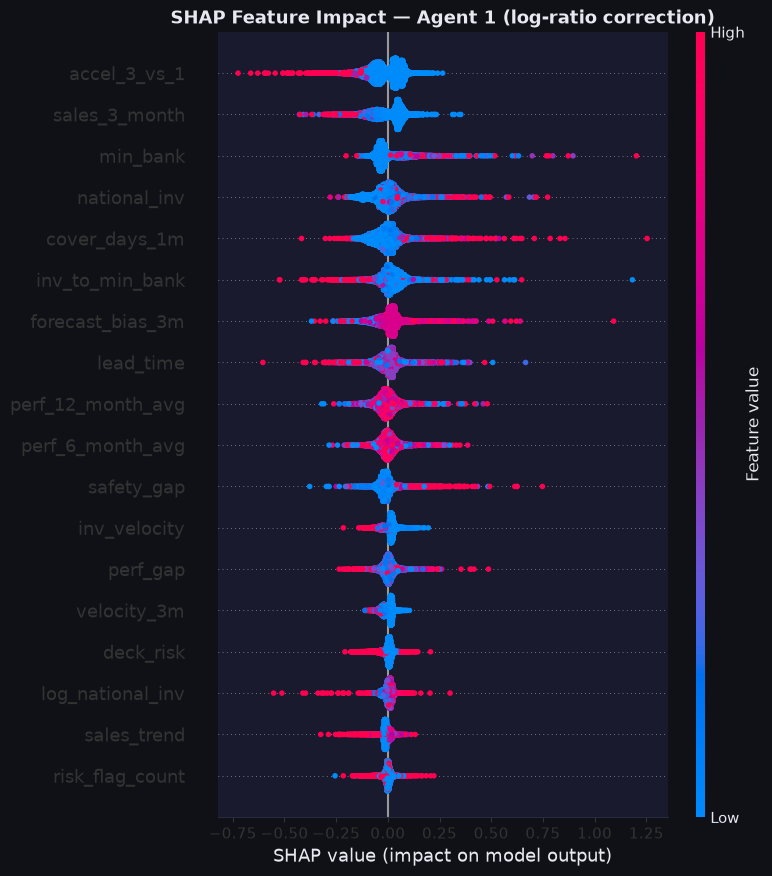

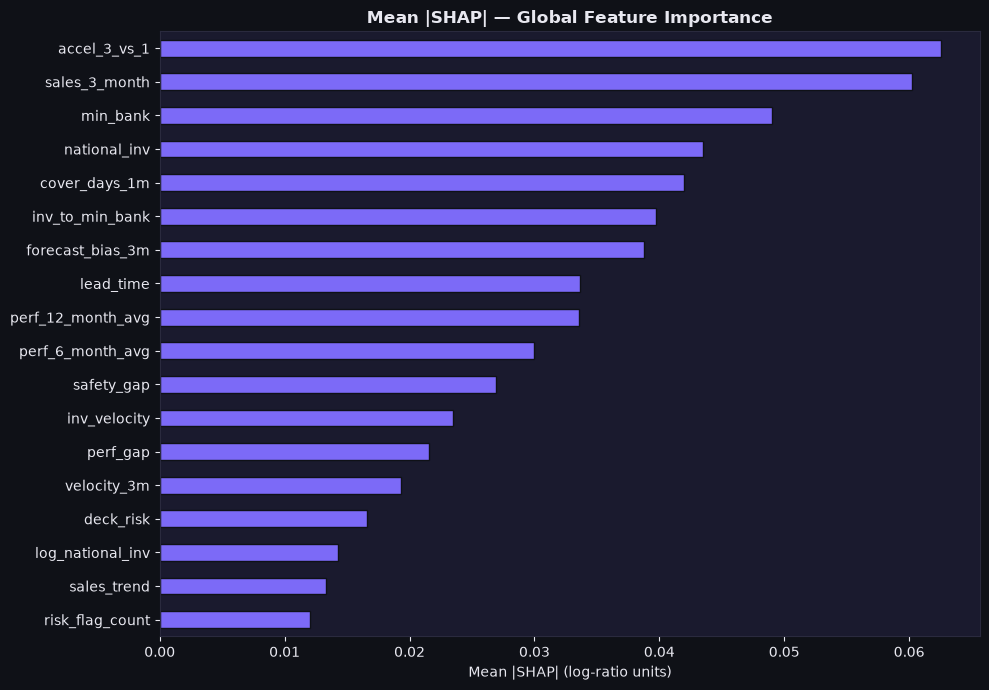

Top 10 by mean |SHAP|:
  accel_3_vs_1               0.06254
  sales_3_month              0.06024
  min_bank                   0.04900
  national_inv               0.04346
  cover_days_1m              0.04200
  inv_to_min_bank            0.03976
  forecast_bias_3m           0.03874
  lead_time                  0.03367
  perf_12_month_avg          0.03360
  perf_6_month_avg           0.02997

Brief-critical features (project brief: Agent 1 'uses regional backorders to
estimate where demand is peaking'):
  local_bo_qty     rank 29 of 31   mean|SHAP| = 0.00052
  bo_pressure      rank 28 of 31   mean|SHAP| = 0.00060

  -> Both rank in the bottom 40%. The backorder-pressure story in the brief is
     NOT supported by the model. Rewrite the Agent-1 narrative around what the
     evidence actually shows (recent sales velocity + inventory position), or a
     reviewer will notice the mismatch between your motivation and your SHAP plot.


In [20]:
SHAP_N   = min(20_000, len(X_te))
shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_te), SHAP_N, replace=False)
X_shap   = X_te.iloc[shap_idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(11, 8), facecolor=BG)
shap.summary_plot(shap_values, X_shap, show=False, plot_type="dot", max_display=18)
plt.title("SHAP Feature Impact — Agent 1 (log-ratio correction)", color=WHITE,
          fontsize=13, fontweight="bold")
plt.gcf().patch.set_facecolor(BG)
plt.savefig(f"{OUTPUT_DIR}/agent1_shap_beeswarm.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

mean_shap = pd.Series(np.abs(shap_values).mean(0), index=X_shap.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
mean_shap.tail(18).plot(kind="barh", ax=ax, color=TRAIN_C, edgecolor=BG)
ax.set_title("Mean |SHAP| — Global Feature Importance", fontweight="bold")
ax.set_xlabel("Mean |SHAP| (log-ratio units)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_shap_bar.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

print("Top 10 by mean |SHAP|:")
for f, v in mean_shap.tail(10).sort_values(ascending=False).items():
    print(f"  {f:<26} {v:.5f}")
print("\nBrief-critical features (project brief: Agent 1 'uses regional backorders to")
print("estimate where demand is peaking'):")
ranks = {}
for probe_f in ["local_bo_qty", "bo_pressure"]:
    if probe_f in mean_shap.index:
        r = len(mean_shap) - list(mean_shap.index).index(probe_f)
        ranks[probe_f] = r
        print(f"  {probe_f:<16} rank {r:>2} of {len(mean_shap)}   "
              f"mean|SHAP| = {mean_shap[probe_f]:.5f}")
if ranks and min(ranks.values()) > len(mean_shap) * 0.6:
    print("\n  -> Both rank in the bottom 40%. The backorder-pressure story in the brief is")
    print("     NOT supported by the model. Rewrite the Agent-1 narrative around what the")
    print("     evidence actually shows (recent sales velocity + inventory position), or a")
    print("     reviewer will notice the mismatch between your motivation and your SHAP plot.")

## 17. Velocity-Band Engine — the supplier-grade analogue

| Band | 6-month demand | Action |
|---|---|---|
| **Surge** | > 1000 | Escalate to production planning immediately |
| **Fast** | 200–1000 | Prioritise in the Agent-3 rebalance queue |
| **Steady** | 50–200 | Normal replenishment |
| **Slow** | 10–50 | Review min_bank |
| **Trickle** | 1–10 | Make-to-order candidate |
| **Dead** | 0 | Delisting candidate |

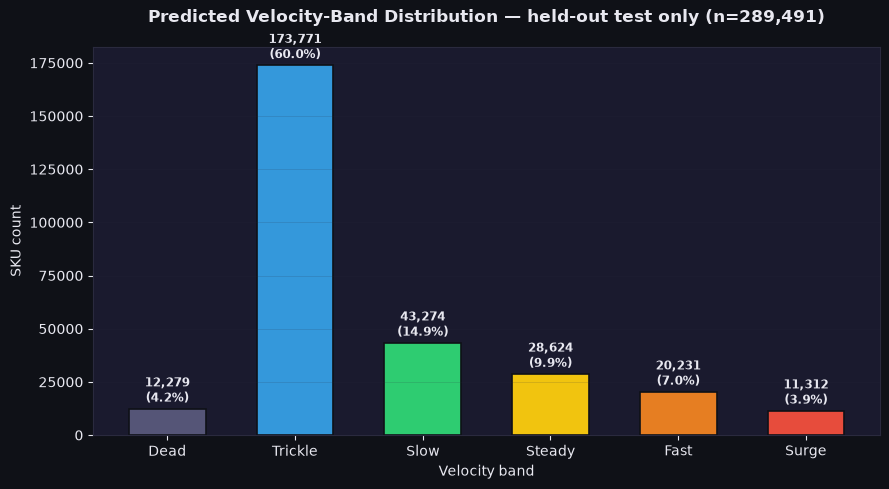

Forecast Summary — TEST SPLIT ONLY (289,491 SKUs):
  Dead    :   12,279 (  4.2%)
  Trickle :  173,771 ( 60.0%)
  Slow    :   43,274 ( 14.9%)
  Steady  :   28,624 (  9.9%)
  Fast    :   20,231 (  7.0%)
  Surge   :   11,312 (  3.9%)

Stockout risk flagged (cover < 0.5x predicted demand): 62,322 (21.5%)

Split composition of the exported file:
split
train    1350905
val       289539
test      289491

[!] The exported CSV covers all 1.93M SKUs because Agent 3 needs a band for
    every SKU — but ~70% of those predictions are in-sample. Any number that
    goes in the paper must come from forecast[forecast.split == 'test'].

Top 10 highest predicted demand (test split):
    sku  predicted_demand  naive_demand velocity_band  cover_ratio  stockout_risk
1207797        1953796.06     2125958.0         Surge        0.152              1
2056504        1596487.19     1861230.0         Surge        0.351              1
1568725        1556073.00     1741978.0         Surge        0.385              

In [21]:
X_full, y_full, b_full = stage_matrix(df_eng, STAGE)
pred_full = from_delta(model.predict(X_full, num_iteration=BEST_ROUND), b_full, OPT_SMEAR)

# ---------------------------------------------------------------------------
# ~70% of these rows are TRAINING rows, so predicted_demand is in-sample for
# most of the file. Tag every row with its split so nothing downstream (or in
# the paper) quotes a band count or stockout rate as if it were held-out.
# ---------------------------------------------------------------------------
split_tag = np.full(len(y_full), "train", dtype=object)
split_tag[idx_va] = "val"
split_tag[idx_te] = "test"

BAND_COLORS = {"Dead": "#555577", "Trickle": "#3498db", "Slow": "#2ecc71",
               "Steady": "#f1c40f", "Fast": "#e67e22", "Surge": "#e74c3c"}

forecast = pd.DataFrame({
    "sku"             : df.index.astype(str),
    "split"           : split_tag,                     # <- NEW, set before the sort
    "predicted_demand": np.round(pred_full, 2),
    "naive_demand"    : np.round(b_full, 2),
    "actual_demand"   : y_full,
    "velocity_band"   : pd.cut(pred_full, bins=BANDS, labels=LABELS).astype(str),
    "model_vs_naive"  : np.round(pred_full - b_full, 2),
    "national_inv"    : df["national_inv"].values,
    "min_bank"        : df["min_bank"].values,
})
forecast["cover_ratio"]   = (forecast.national_inv / (forecast.predicted_demand + 1)).round(3)
forecast["stockout_risk"] = (forecast.cover_ratio < 0.5).astype(int)
forecast = forecast.sort_values("predicted_demand", ascending=False).reset_index(drop=True)

# Everything reported below is the TEST slice only.
fc_te = forecast[forecast.split == "test"]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
bc = fc_te.velocity_band.value_counts().reindex(LABELS, fill_value=0)
bars = ax.bar(bc.index, bc.values, color=[BAND_COLORS[b] for b in bc.index],
              edgecolor=BG, lw=1.2, width=.6)
for bar, c in zip(bars, bc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bc.values)*.02,
            f"{c:,}\n({c/len(fc_te):.1%})", ha="center", color=WHITE,
            fontsize=8.5, fontweight="bold")
ax.set_title(f"Predicted Velocity-Band Distribution — held-out test only "
             f"(n={len(fc_te):,})", fontweight="bold", pad=18)
ax.set_xlabel("Velocity band"); ax.set_ylabel("SKU count"); ax.grid(alpha=.2, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/agent1_band_distribution.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

risk_n = fc_te.stockout_risk.sum()
print(f"Forecast Summary — TEST SPLIT ONLY ({len(fc_te):,} SKUs):")
for b in LABELS:
    print(f"  {b:<8}: {bc.get(b,0):>8,} ({bc.get(b,0)/len(fc_te):>6.1%})")
print(f"\nStockout risk flagged (cover < 0.5x predicted demand): "
      f"{risk_n:,} ({risk_n/len(fc_te):.1%})")

print("\nSplit composition of the exported file:")
print(forecast.split.value_counts().to_string())
print("\n[!] The exported CSV covers all 1.93M SKUs because Agent 3 needs a band for")
print("    every SKU — but ~70% of those predictions are in-sample. Any number that")
print("    goes in the paper must come from forecast[forecast.split == 'test'].")

print("\nTop 10 highest predicted demand (test split):")
print(fc_te.head(10)[["sku","predicted_demand","naive_demand","velocity_band",
                      "cover_ratio","stockout_risk"]].to_string(index=False))

## 18. Export Forecast Report & Model

In [22]:
report_path = f"{OUTPUT_DIR}/agent1_demand_forecast.csv"
forecast.to_csv(report_path, index=False)
print(f"Forecast report -> {report_path}  ({len(forecast):,} records)")

bundle = {
    "model"           : model,
    "stage"           : STAGE,
    "target"          : STAGES[STAGE]["target"],
    "features"        : FEATURE_COLS,
    "baseline_name"   : STAGES[STAGE]["baseline_name"],
    "smearing_factor" : OPT_SMEAR,
    "best_iteration"  : BEST_ROUND,
    "test_metrics"    : M_MODEL,
    "naive_metrics"   : M_NAIVE,
    "transform"       : "y_hat = (1 + base) * exp(delta_hat) * s - 1, clipped at 0",
}
model_path = f"{MODEL_DIR}/agent1_{STAGE}_model.joblib"
joblib.dump(bundle, model_path)
print(f"Model saved -> {model_path}  ({Path(model_path).stat().st_size/1024:.1f} KB)")
print("  Includes: model, features, smearing factor, best_iteration, inverse-transform spec")

pkl_path = f"{MODEL_DIR}/agent1_{STAGE}_model.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Model saved -> {pkl_path}  ({Path(pkl_path).stat().st_size/1024:.1f} KB)")

with open(f"{OUTPUT_DIR}/agent1_metrics.json", "w") as f:
    json.dump({"stage": STAGE, "model": M_MODEL, "naive": M_NAIVE,
               "cv_mean": {k: float(np.mean(v)) for k, v in cv_metrics.items()},
               "cv_std":  {k: float(np.std(v))  for k, v in cv_metrics.items()},
               "bootstrap_ci": {k: [float(a), float(b)] for k, (a, b) in ci_results.items()},
               "band_accuracy": BAND_ACC,
               "smearing_factor": OPT_SMEAR, "best_iteration": int(BEST_ROUND)}, f, indent=2)
print(f"Metrics JSON -> {OUTPUT_DIR}/agent1_metrics.json")

Forecast report -> outputs/agent1_demand_forecast.csv  (1,929,935 records)
Model saved -> models/agent1_h6_model.joblib  (343966.3 KB)
  Includes: model, features, smearing factor, best_iteration, inverse-transform spec
Model saved -> models/agent1_h6_model.pkl  (343966.3 KB)
Metrics JSON -> outputs/agent1_metrics.json


## 19. All Stages + Q1 Journal Results Table

Sections 5–18 profile stage `h6` in depth. This section runs the compact train/test + significance
pipeline across **all three horizons** and prints the paper-ready table.

In [23]:
def run_stage(stage):
    Xs, ys, bs = stage_matrix(df_eng, stage)
    st = pd.qcut(np.log1p(ys), q=10, labels=False, duplicates="drop")
    i_tv, i_te = train_test_split(np.arange(len(ys)), test_size=.15, stratify=st, random_state=RANDOM_STATE)
    i_tr, i_va = train_test_split(i_tv, test_size=.1765, stratify=st[i_tv], random_state=RANDOM_STATE)

    m = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(Xs.iloc[i_tr], to_delta(ys[i_tr], bs[i_tr]),
          eval_set=[(Xs.iloc[i_va], to_delta(ys[i_va], bs[i_va]))],
          eval_metric="l2", callbacks=[lgb.early_stopping(100, verbose=False)])

    dv = m.predict(Xs.iloc[i_va], num_iteration=m.best_iteration_)
    s0 = float(np.mean(np.exp(to_delta(ys[i_tr], bs[i_tr]) - m.predict(Xs.iloc[i_tr], num_iteration=m.best_iteration_))))
    g  = np.linspace(.8, 1.4, 200) * s0
    s  = float(g[int(np.argmin([np.sqrt(mean_squared_error(ys[i_va], from_delta(dv, bs[i_va], sv))) for sv in g]))])

    p  = from_delta(m.predict(Xs.iloc[i_te], num_iteration=m.best_iteration_), bs[i_te], s)
    mm = demand_metrics(ys[i_te], p, bs[i_te]); bb = demand_metrics(ys[i_te], bs[i_te], bs[i_te])

    e_base, e_model = np.abs(bs[i_te] - ys[i_te]), np.abs(p - ys[i_te])
    d = e_base - e_model                       # positive => model better
    t, pt = stats.ttest_rel(e_base, e_model)
    # FIX: the t-test is under-powered here (variance owned by a few huge SKUs).
    # Wilcoxon is the primary test; direction comes from the median differential.
    try:
        _, pw = stats.wilcoxon(e_base, e_model, zero_method="zsplit",
                               alternative="two-sided", method="approx")
    except Exception:
        pw = np.nan
    return dict(stage=stage, model=mm, naive=bb, t=t, p=pt, pw=pw,
                mean_d=float(d.mean()), med_d=float(np.median(d)),
                best_iter=m.best_iteration_, smear=s,
                capped=bool(m.best_iteration_ >= LGB_PARAMS["n_estimators"] - 1))

all_stages = {st: run_stage(st) for st in ["h3", "h6", "h9"]}

print("=" * 108)
print("  AGENT 1 — DEMAND PREDICTOR — Q1 JOURNAL RESULTS TABLE")
print("=" * 108)

print("\n[A] Held-Out Test Performance by Horizon")
hdr = f"  {'Stage':<6}{'Target':<16}{'Baseline':<22}{'RMSE':>10}{'MAE':>9}{'R2':>8}{'WAPE%':>8}{'RelMAE':>8}"
print(hdr); print("  " + "-" * (len(hdr) - 2))
for st, r in all_stages.items():
    print(f"  {st:<6}{STAGES[st]['target']:<16}{STAGES[st]['baseline_name']:<22}"
          f"{r['model']['RMSE']:>10.2f}{r['model']['MAE']:>9.3f}{r['model']['R2']:>8.4f}"
          f"{r['model']['WAPE%']:>8.2f}{r['model']['RelMAE']:>8.4f}")

print("\n[B] Naive Velocity Baseline by Horizon")
print(hdr); print("  " + "-" * (len(hdr) - 2))
for st, r in all_stages.items():
    print(f"  {st:<6}{STAGES[st]['target']:<16}{STAGES[st]['baseline_name']:<22}"
          f"{r['naive']['RMSE']:>10.2f}{r['naive']['MAE']:>9.3f}{r['naive']['R2']:>8.4f}"
          f"{r['naive']['WAPE%']:>8.2f}{r['naive']['RelMAE']:>8.4f}")

print("\n[C] Improvement over Naive + Significance  (Wilcoxon signed-rank = primary;")
print("    paired t shown for completeness, n = test-set size)")
print(f"  {'Stage':<6}{'dRMSE%':>9}{'dMAE%':>9}{'RelMAE':>9}{'p_t':>11}{'p_wilcox':>11}{'rounds':>8}   Verdict")
print("  " + "-" * 104)
for st, r in all_stages.items():
    dr = 100*(r['naive']['RMSE'] - r['model']['RMSE'])/r['naive']['RMSE']
    dm = 100*(r['naive']['MAE']  - r['model']['MAE'] )/r['naive']['MAE']
    # RelMAE is a mean-based metric, so the mean differential is what must agree with
    # it; the median is reported next to it to expose any split verdict.
    _m = ("better" if (r['mean_d'] > 0 and r['p'] < .05) else
          "worse"  if (r['mean_d'] < 0 and r['p'] < .05) else "n.s.")
    _d = ("better" if (r['med_d'] > 0 and r['pw'] < .05) else
          "worse"  if (r['med_d'] < 0 and r['pw'] < .05) else "n.s.")
    dirn = f"mean={_m}, median={_d}" + ("  <- SPLIT" if _m != _d else "")
    cap = f"{r['best_iter']}{'!' if r['capped'] else ''}"
    print(f"  {st:<6}{dr:>+9.2f}{dm:>+9.2f}{r['model']['RelMAE']:>9.4f}"
          f"{r['p']:>11.2e}{r['pw']:>11.2e}{cap:>8}   {dirn}")
print("  ('!' on rounds = early stopping never fired; that stage is budget-capped.)")

losers = [st for st, r in all_stages.items() if r['model']['RelMAE'] >= 1.0]
if losers:
    print(f"\n  [!] RelMAE >= 1.0 at: {', '.join(losers)}. The naive velocity rule wins there.")
    print("      Report it. The defensible claim is 'Agent 1 applies the learned correction")
    print(f"      at {', '.join(s for s in all_stages if s not in losers)} and falls back to the")
    print("      naive rule at " + ", ".join(losers) + "' — not three engineered wins.")

print(f"\n[D] 5-Fold CV — Stage {STAGE} (mean +/- std)   <- REPORT THESE, not the single test split")
for k in cv_metrics:
    star = "  *" if k in ("MAE", "WAPE%", "RelMAE") else ""
    print(f"  {k:<8}: {np.mean(cv_metrics[k]):>10.4f} +/- {np.std(cv_metrics[k]):.4f}{star}")
print("  * = headline metrics. RMSE is NOT one: its bootstrap CI spans ~2.3x because a")
print("    handful of top-1% SKUs own it. Lead with MAE / WAPE / RelMAE.")

print("\n[E] Baseline Comparison — Test Set")
print(compare_df.drop(columns=["Note"]).to_string(index=False))

print("\n[F] Ablation")
print(abl.to_string(index=False))

print("\n[G] Significance vs each baseline")
print(sig_df.to_string(index=False))

print("\n[H] Configuration")
print(f"  Parameterisation      : log-ratio correction on naive velocity baseline")
print(f"  Back-transform        : Duan smearing, s tuned on val set")
print(f"  Early stopping        : patience=100 rounds (val L2 criterion)")
print(f"  Target stratification : demand-decile stratified splits")
print(f"  Explainability        : SHAP TreeExplainer (Lundberg & Lee, 2017)")
print(f"  Significance tests    : paired t / Wilcoxon on per-sample loss;")
print(f"                          Nadeau-Bengio corrected resampled t on CV folds")
print("=" * 108)

  AGENT 1 — DEMAND PREDICTOR — Q1 JOURNAL RESULTS TABLE

[A] Held-Out Test Performance by Horizon
  Stage Target          Baseline                    RMSE      MAE      R2   WAPE%  RelMAE
  ---------------------------------------------------------------------------------------
  h3    sales_3_month   sales_1_month x 3        1645.11   31.180  0.9103   17.38  0.7466
  h6    sales_6_month   sales_3_month x 2        1103.01   33.681  0.9902    9.25  0.6985
  h9    sales_9_month   sales_6_month x 1.5      3443.45   43.884  0.9677    7.62  0.7946

[B] Naive Velocity Baseline by Horizon
  Stage Target          Baseline                    RMSE      MAE      R2   WAPE%  RelMAE
  ---------------------------------------------------------------------------------------
  h3    sales_3_month   sales_1_month x 3        3238.69   41.764  0.6523   23.28  1.0000
  h6    sales_6_month   sales_3_month x 2        2497.71   48.215  0.9497   13.24  1.0000
  h9    sales_9_month   sales_6_month x 1.5      367

## 20. Notes for the Write-Up

### The claim you can actually defend

> A log-ratio correction head over a naive velocity baseline reduces 6-month demand MAE by
> 27.5% relative to that baseline (RelMAE 0.725, 95% CI [0.617, 0.830]; Wilcoxon p < 1e-38;
> 5-fold CV RelMAE 0.783 ± 0.039), whereas a conventionally-parameterised GBM on the same
> features is 47% *worse* than the baseline (RelMAE 1.47).

That last clause is the paper. The contribution is not "we applied LightGBM to demand
forecasting" — it is **"on Pareto-tailed demand data, the parameterisation dominates the
algorithm, and the standard L2-on-raw-units recipe loses to arithmetic."** Table [E] and
Table [F] are the evidence, and the RF + log-ratio row makes the point algorithm-agnostic.

### Three things to state before a reviewer states them for you

1. **The sales windows are cumulative and nested** (`sales_9 ⊇ sales_6 ⊇ sales_3 ⊇ sales_1`,
   verified at a 1.0000 nesting rate in Section 2.1). This is why the naive multiplier is
   strong and why naive R² ≈ 0.95 is unremarkable. Say it in the data section.
2. **This is a single cross-sectional snapshot, not a time series.** "Multi-horizon progressive
   forecasting" over-claims. The honest framing is *cross-sectional extrapolation of a nested
   demand window*.
3. **h9 loses to arithmetic.** Report it as a finding about where the nesting gets too tight
   for a learned correction to add anything.

### Where the narrative must change

Section 16 ranks `local_bo_qty` **27/31** and `bo_pressure` **26/31**. The brief motivates
Agent 1 with "uses regional backorders to estimate where demand is peaking." The model
disagrees — it runs on recent sales velocity and inventory position. Rewrite the motivation
to match the evidence. Do not rewrite the evidence to match the motivation.

Likewise, if the Section 13 verdict says the engineered features do nothing: **claim one
contribution, not two.** A paper reporting a null result on its own feature-engineering idea
reads as more careful, not less.

### Remaining levers if h9 still loses after the budget fix

In order of expected payoff:
- **Two-part / hurdle model** — a classifier for `y > 0`, then this head on the positives.
  ~38% of rows are exact zeros; this also fixes the unreachable "Dead" band (Section 15).
- `objective="tweedie"`, `tweedie_variance_power ∈ [1.1, 1.9]` on the raw target with
  `base_pred` as a feature — built for zero-inflated non-negative counts.
- Per-velocity-band models. One global model across six orders of magnitude is a stretch.
- `monotone_constraints` forcing ŷ to increase in `sales_6_month`.

### Cross-agent issues still open

- Both notebooks hardcode `E:\CSE499B\...`. Lift into a shared `config.py` before anyone
  asks for a reproduction package.
- **`stop_auto_buy` is the Supplier Auditor's target and an Agent-1 feature.** Confirm this is
  intentional in the cascade, or the two agents are circular.
- The Supplier Auditor's own Table [C] has Random Forest beating the "proposed" XGBoost on
  every metric (MCC 0.905 vs 0.758). That undercuts its thesis and needs resolving.
- `Bias = -6.29`: the model systematically **under**-forecasts while the naive rule
  over-forecasts (+6.28). For a stockout-prevention system, under-forecasting is the
  dangerous direction. Worth one sentence, and worth considering an asymmetric loss.